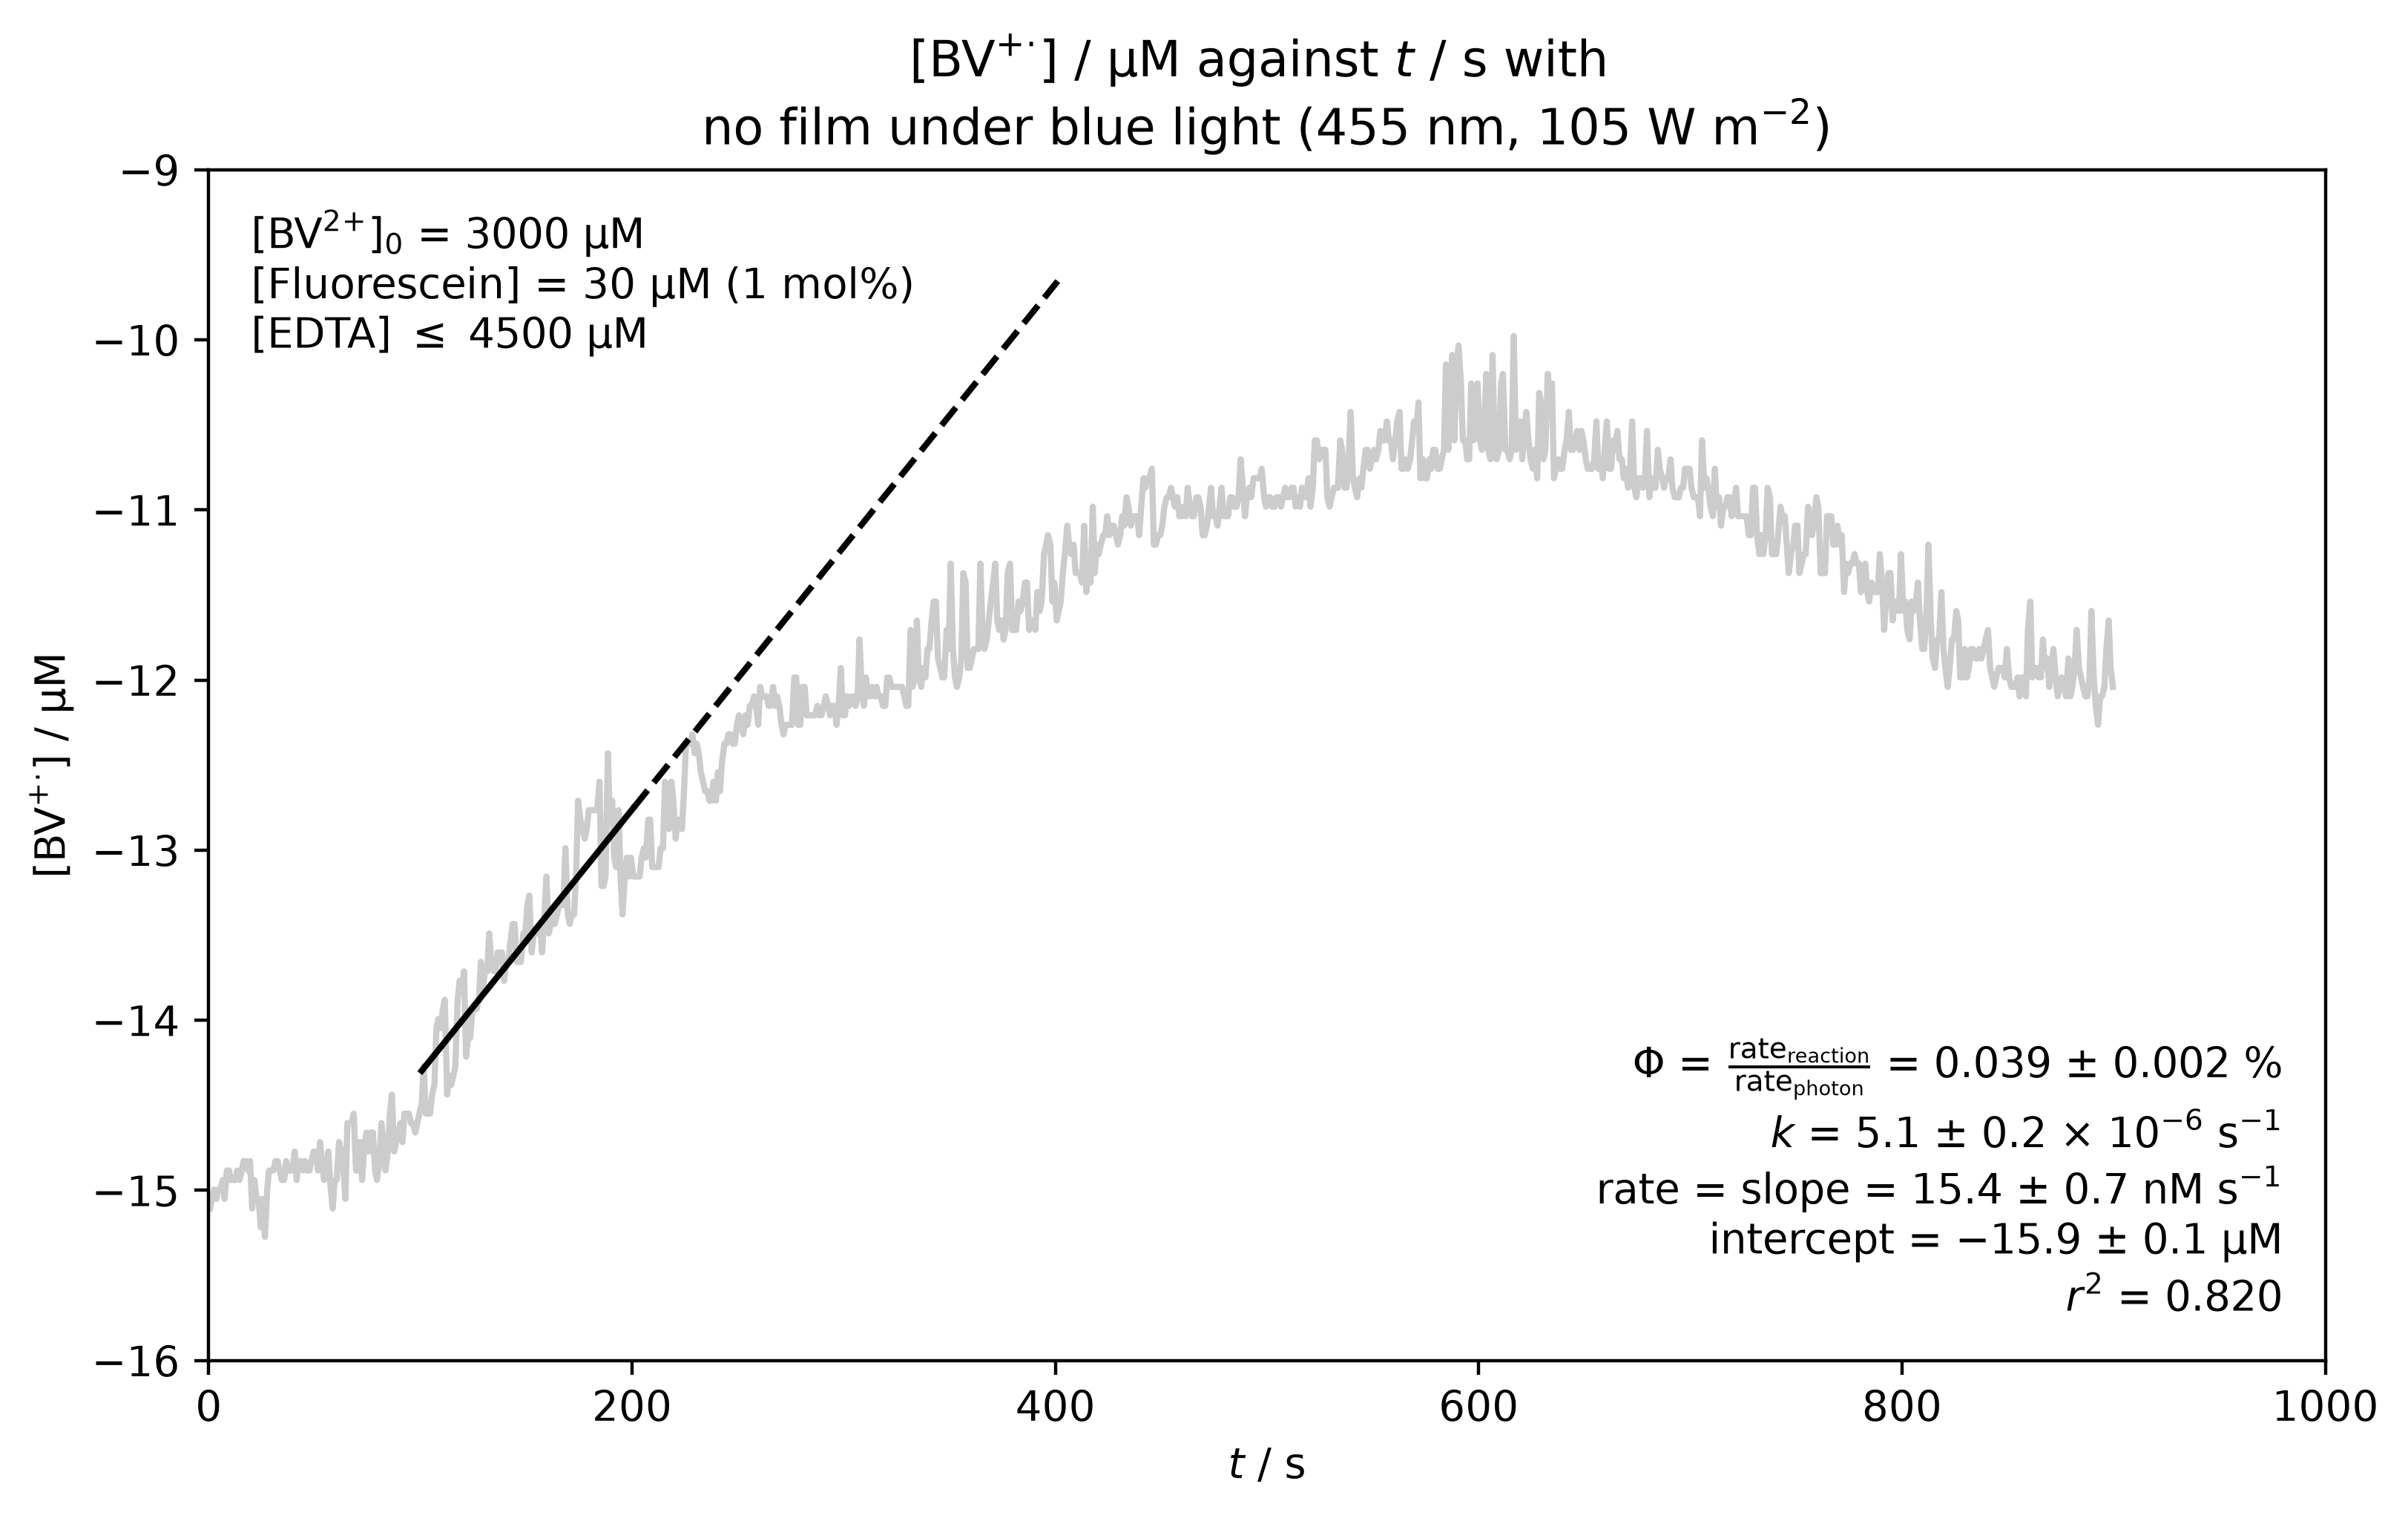

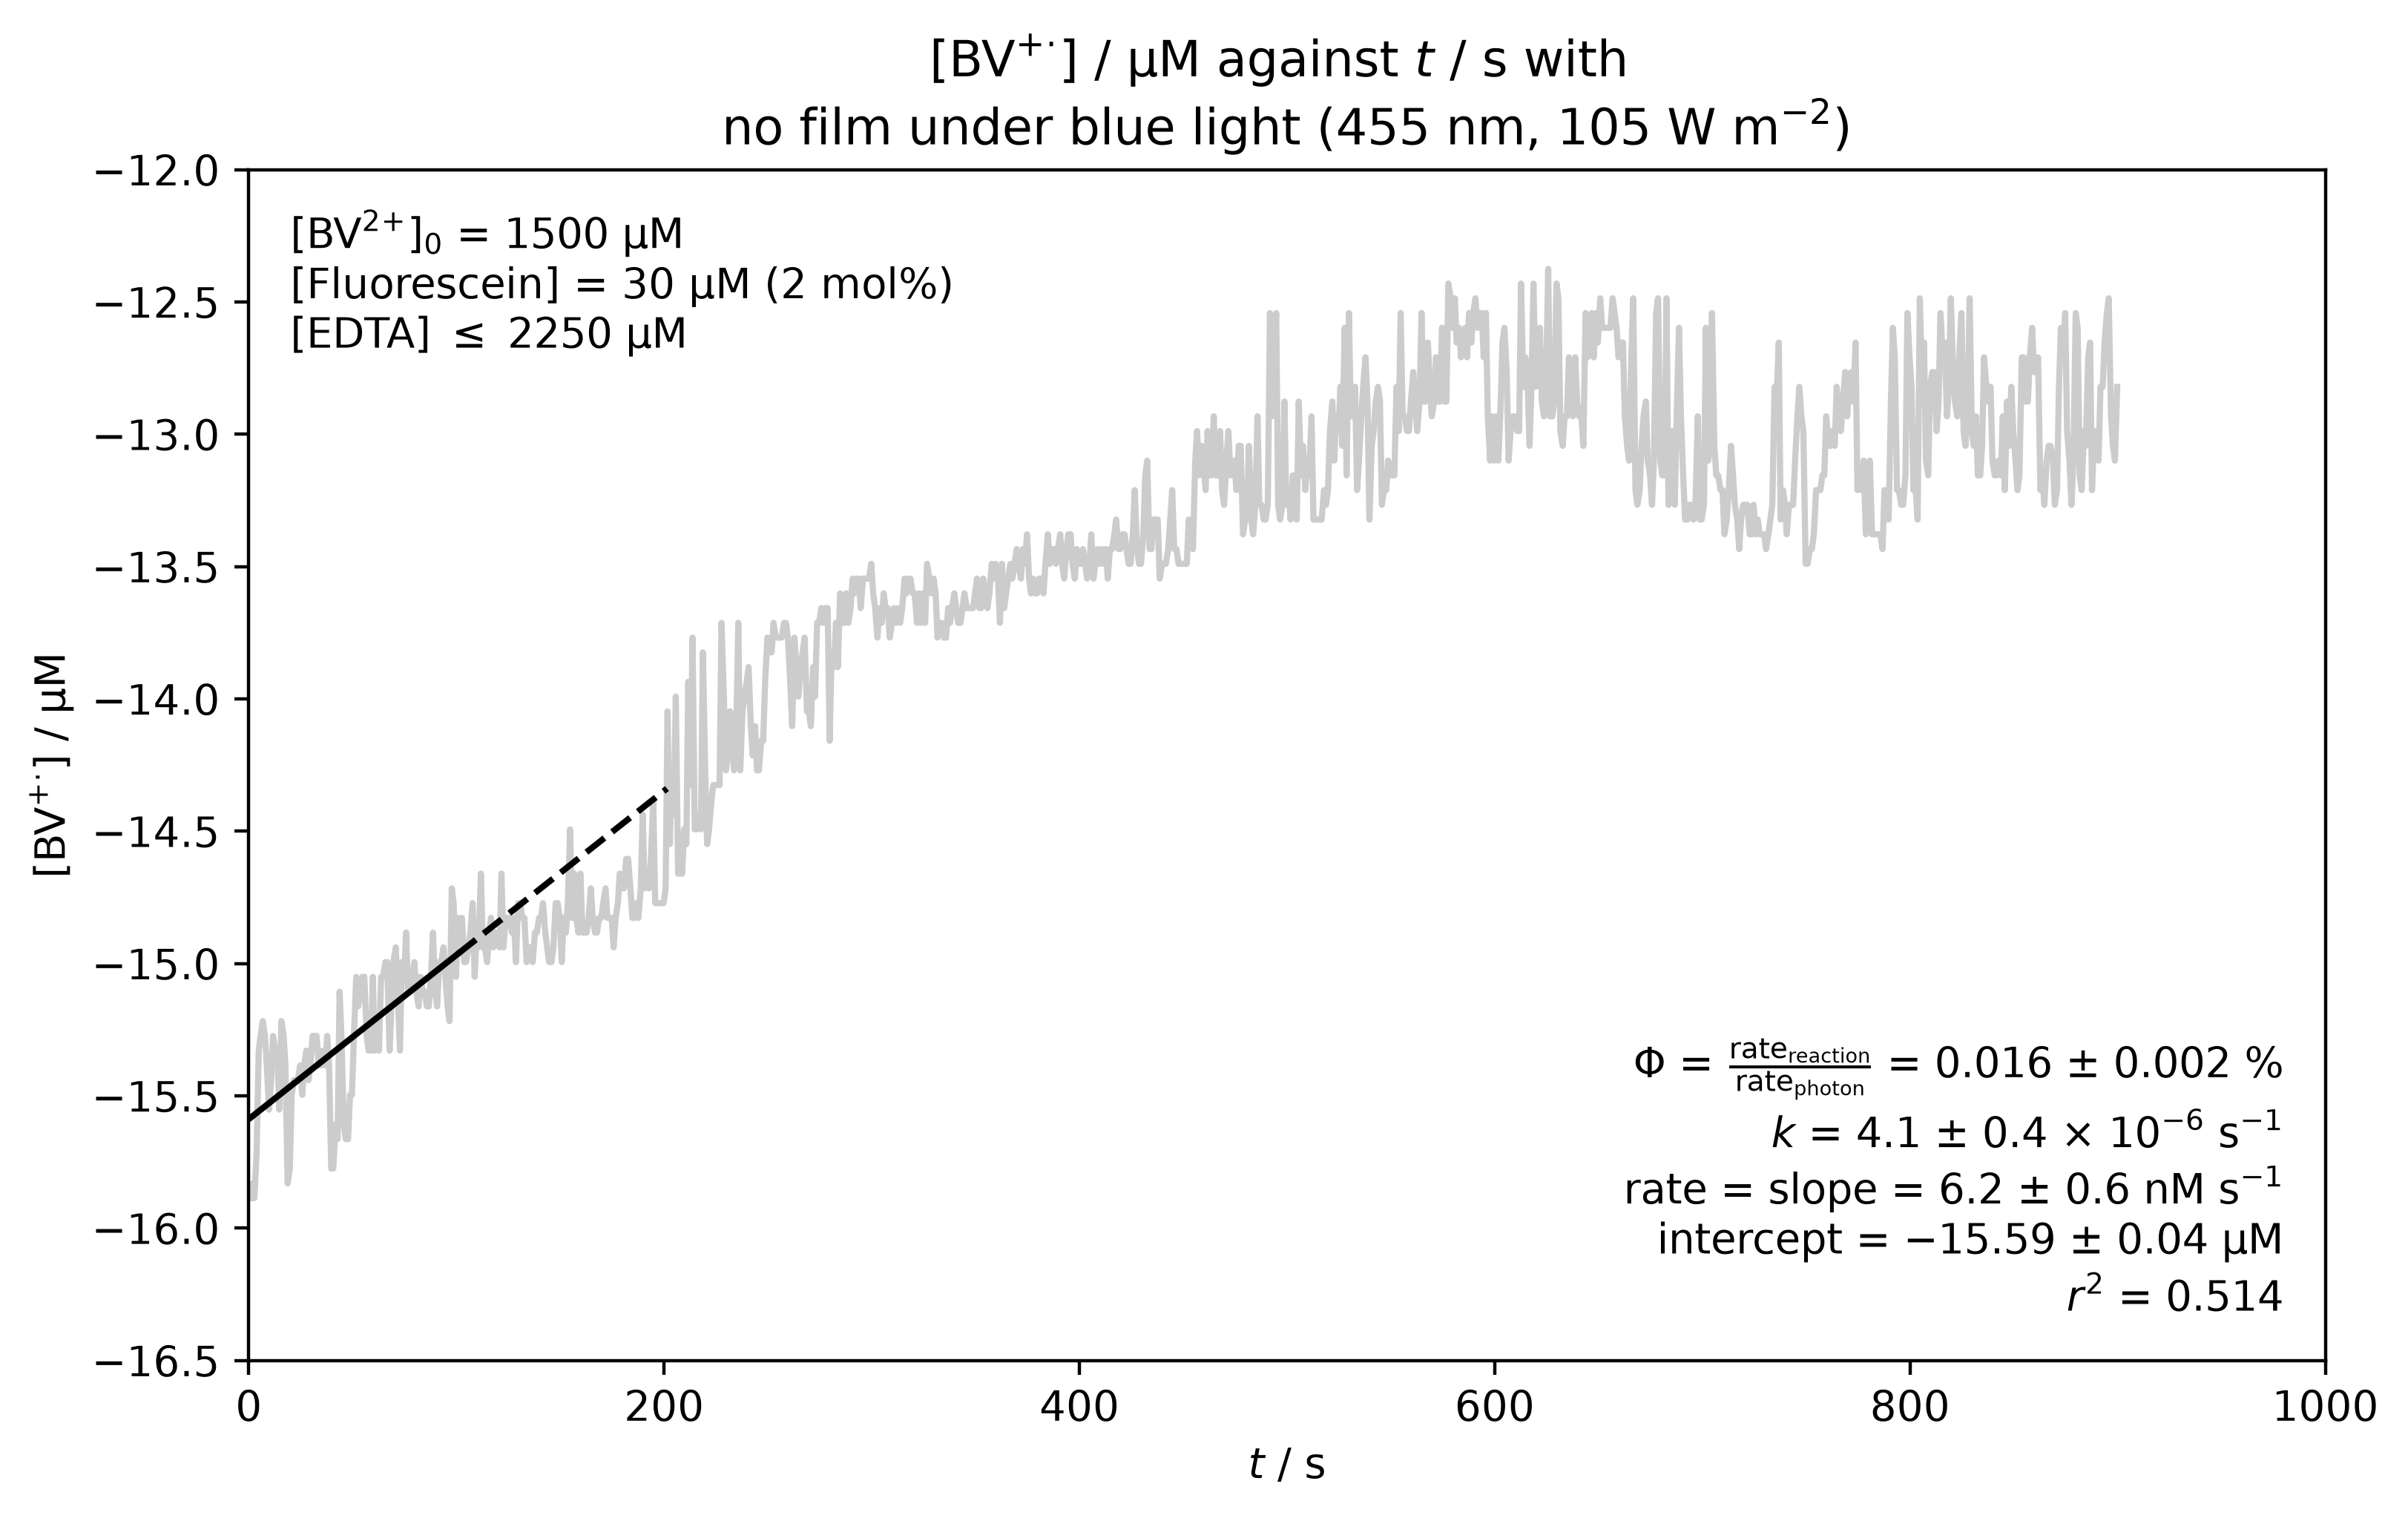

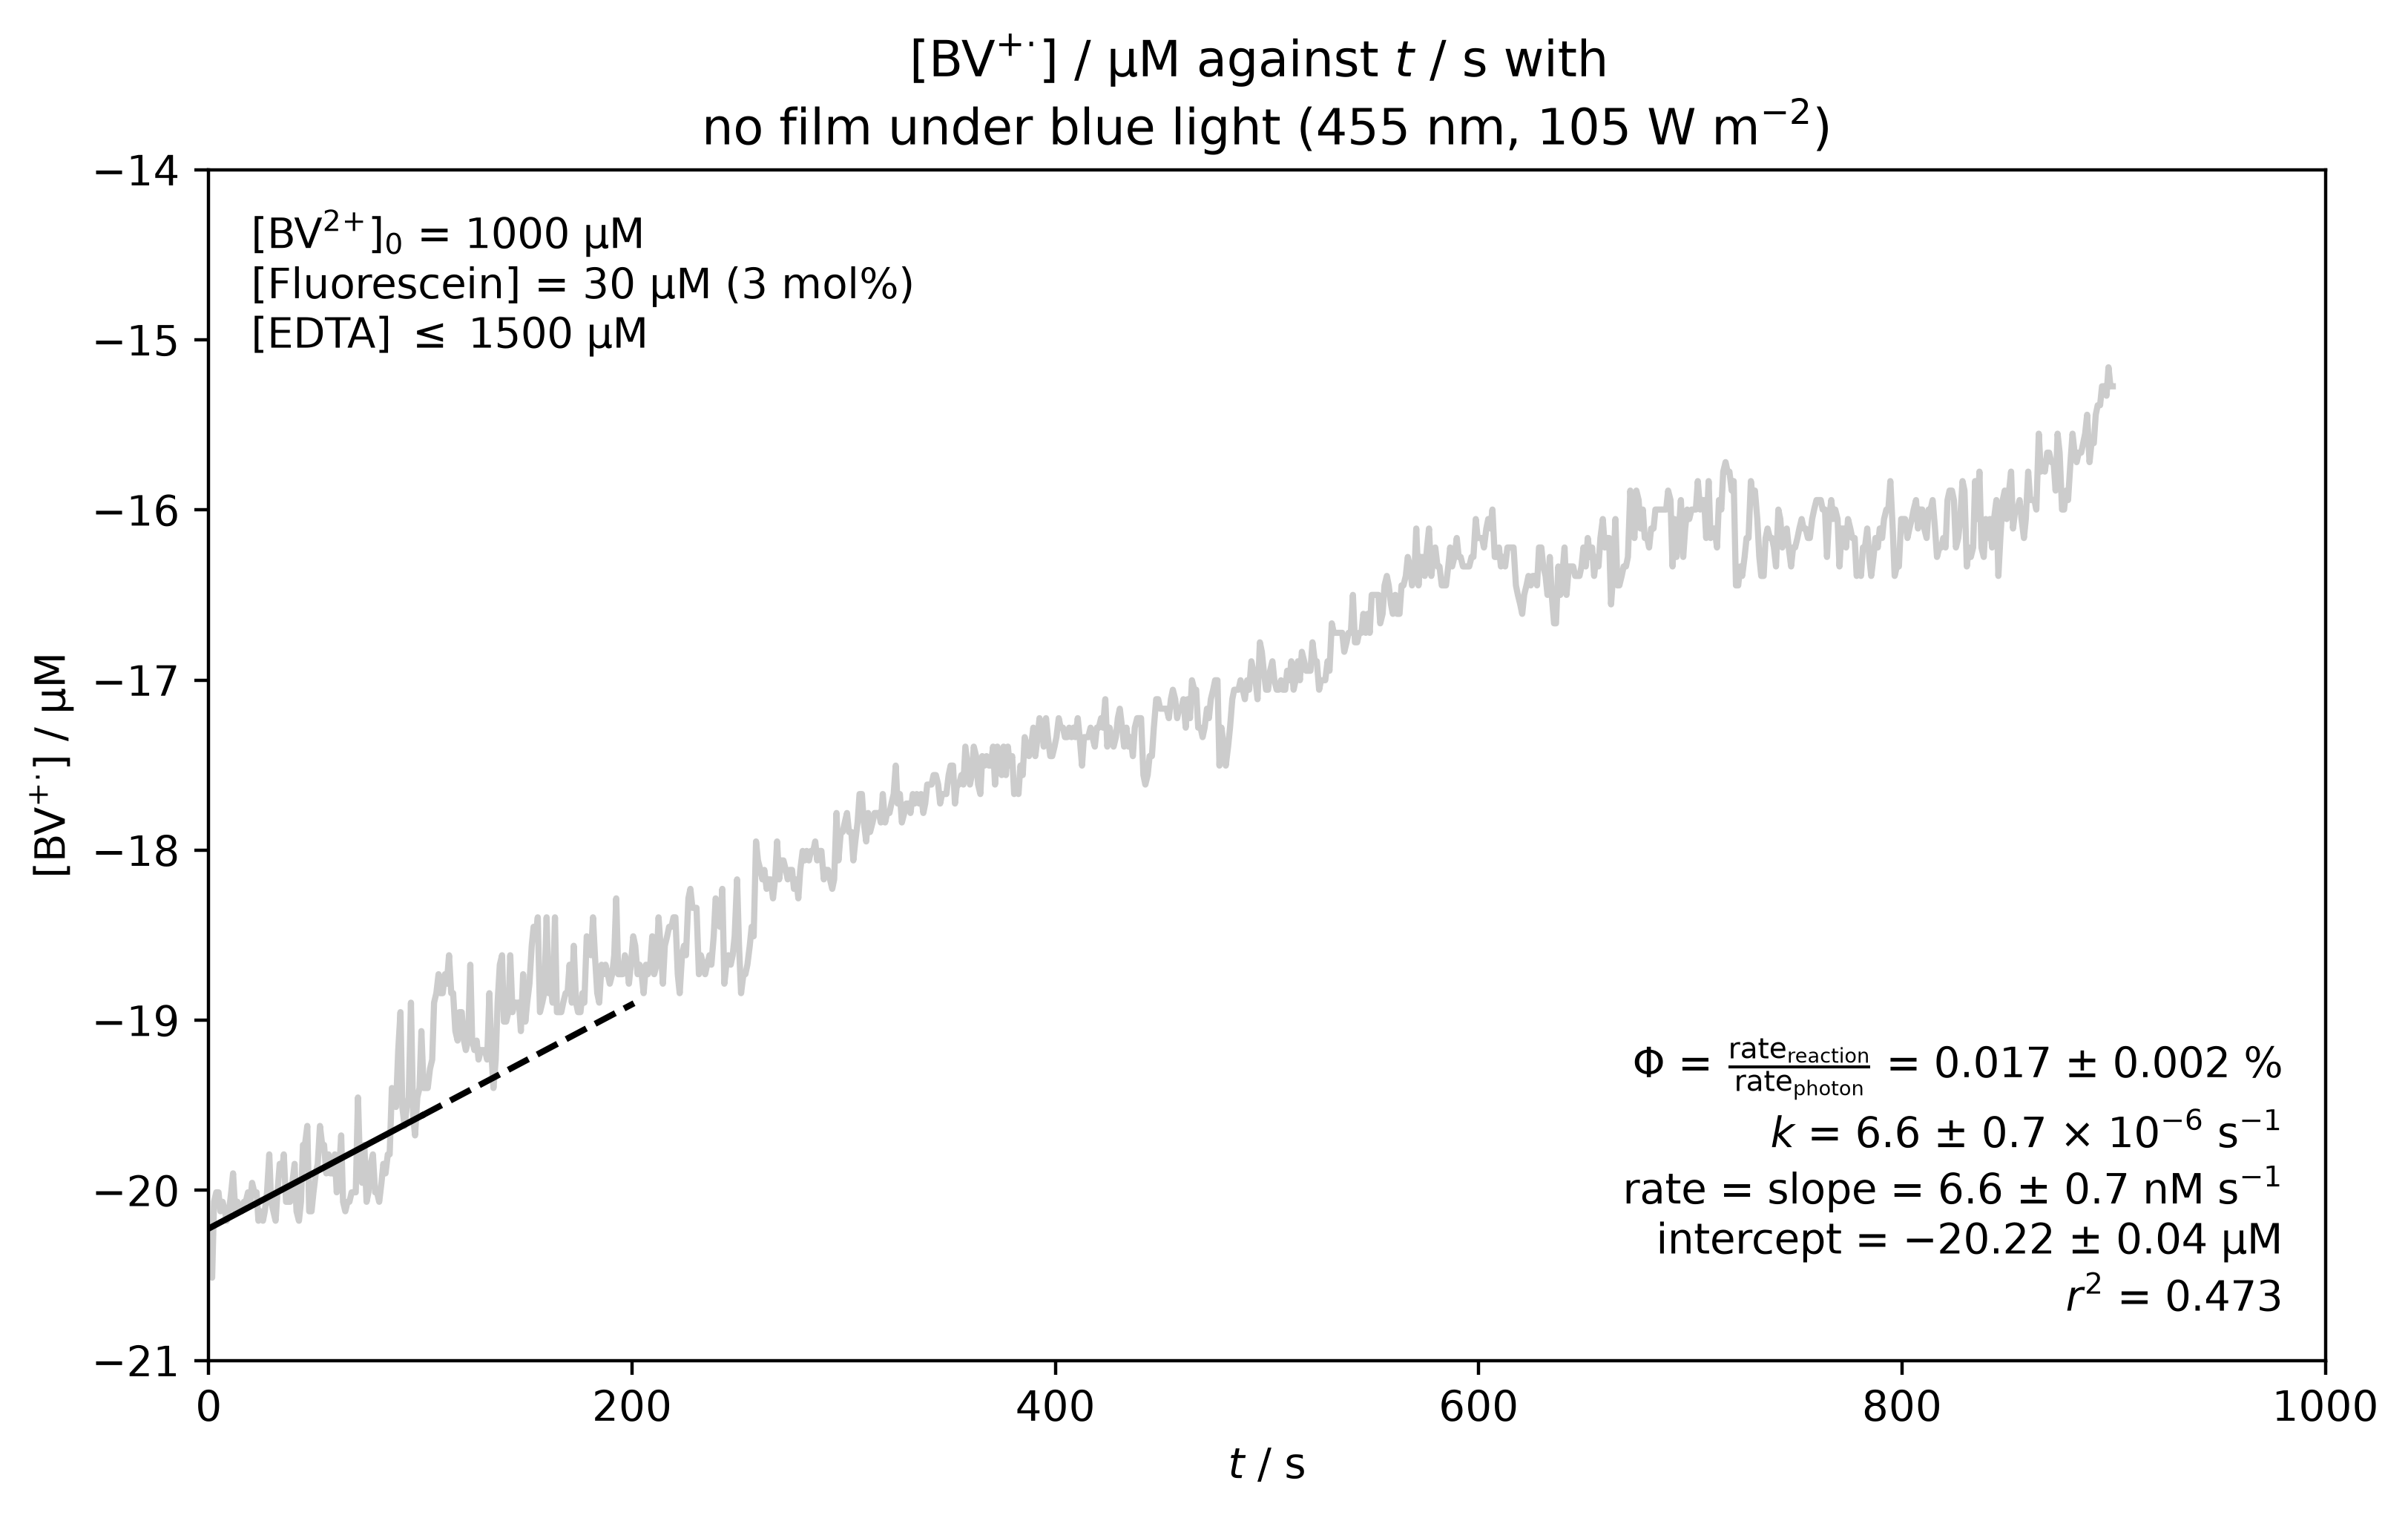

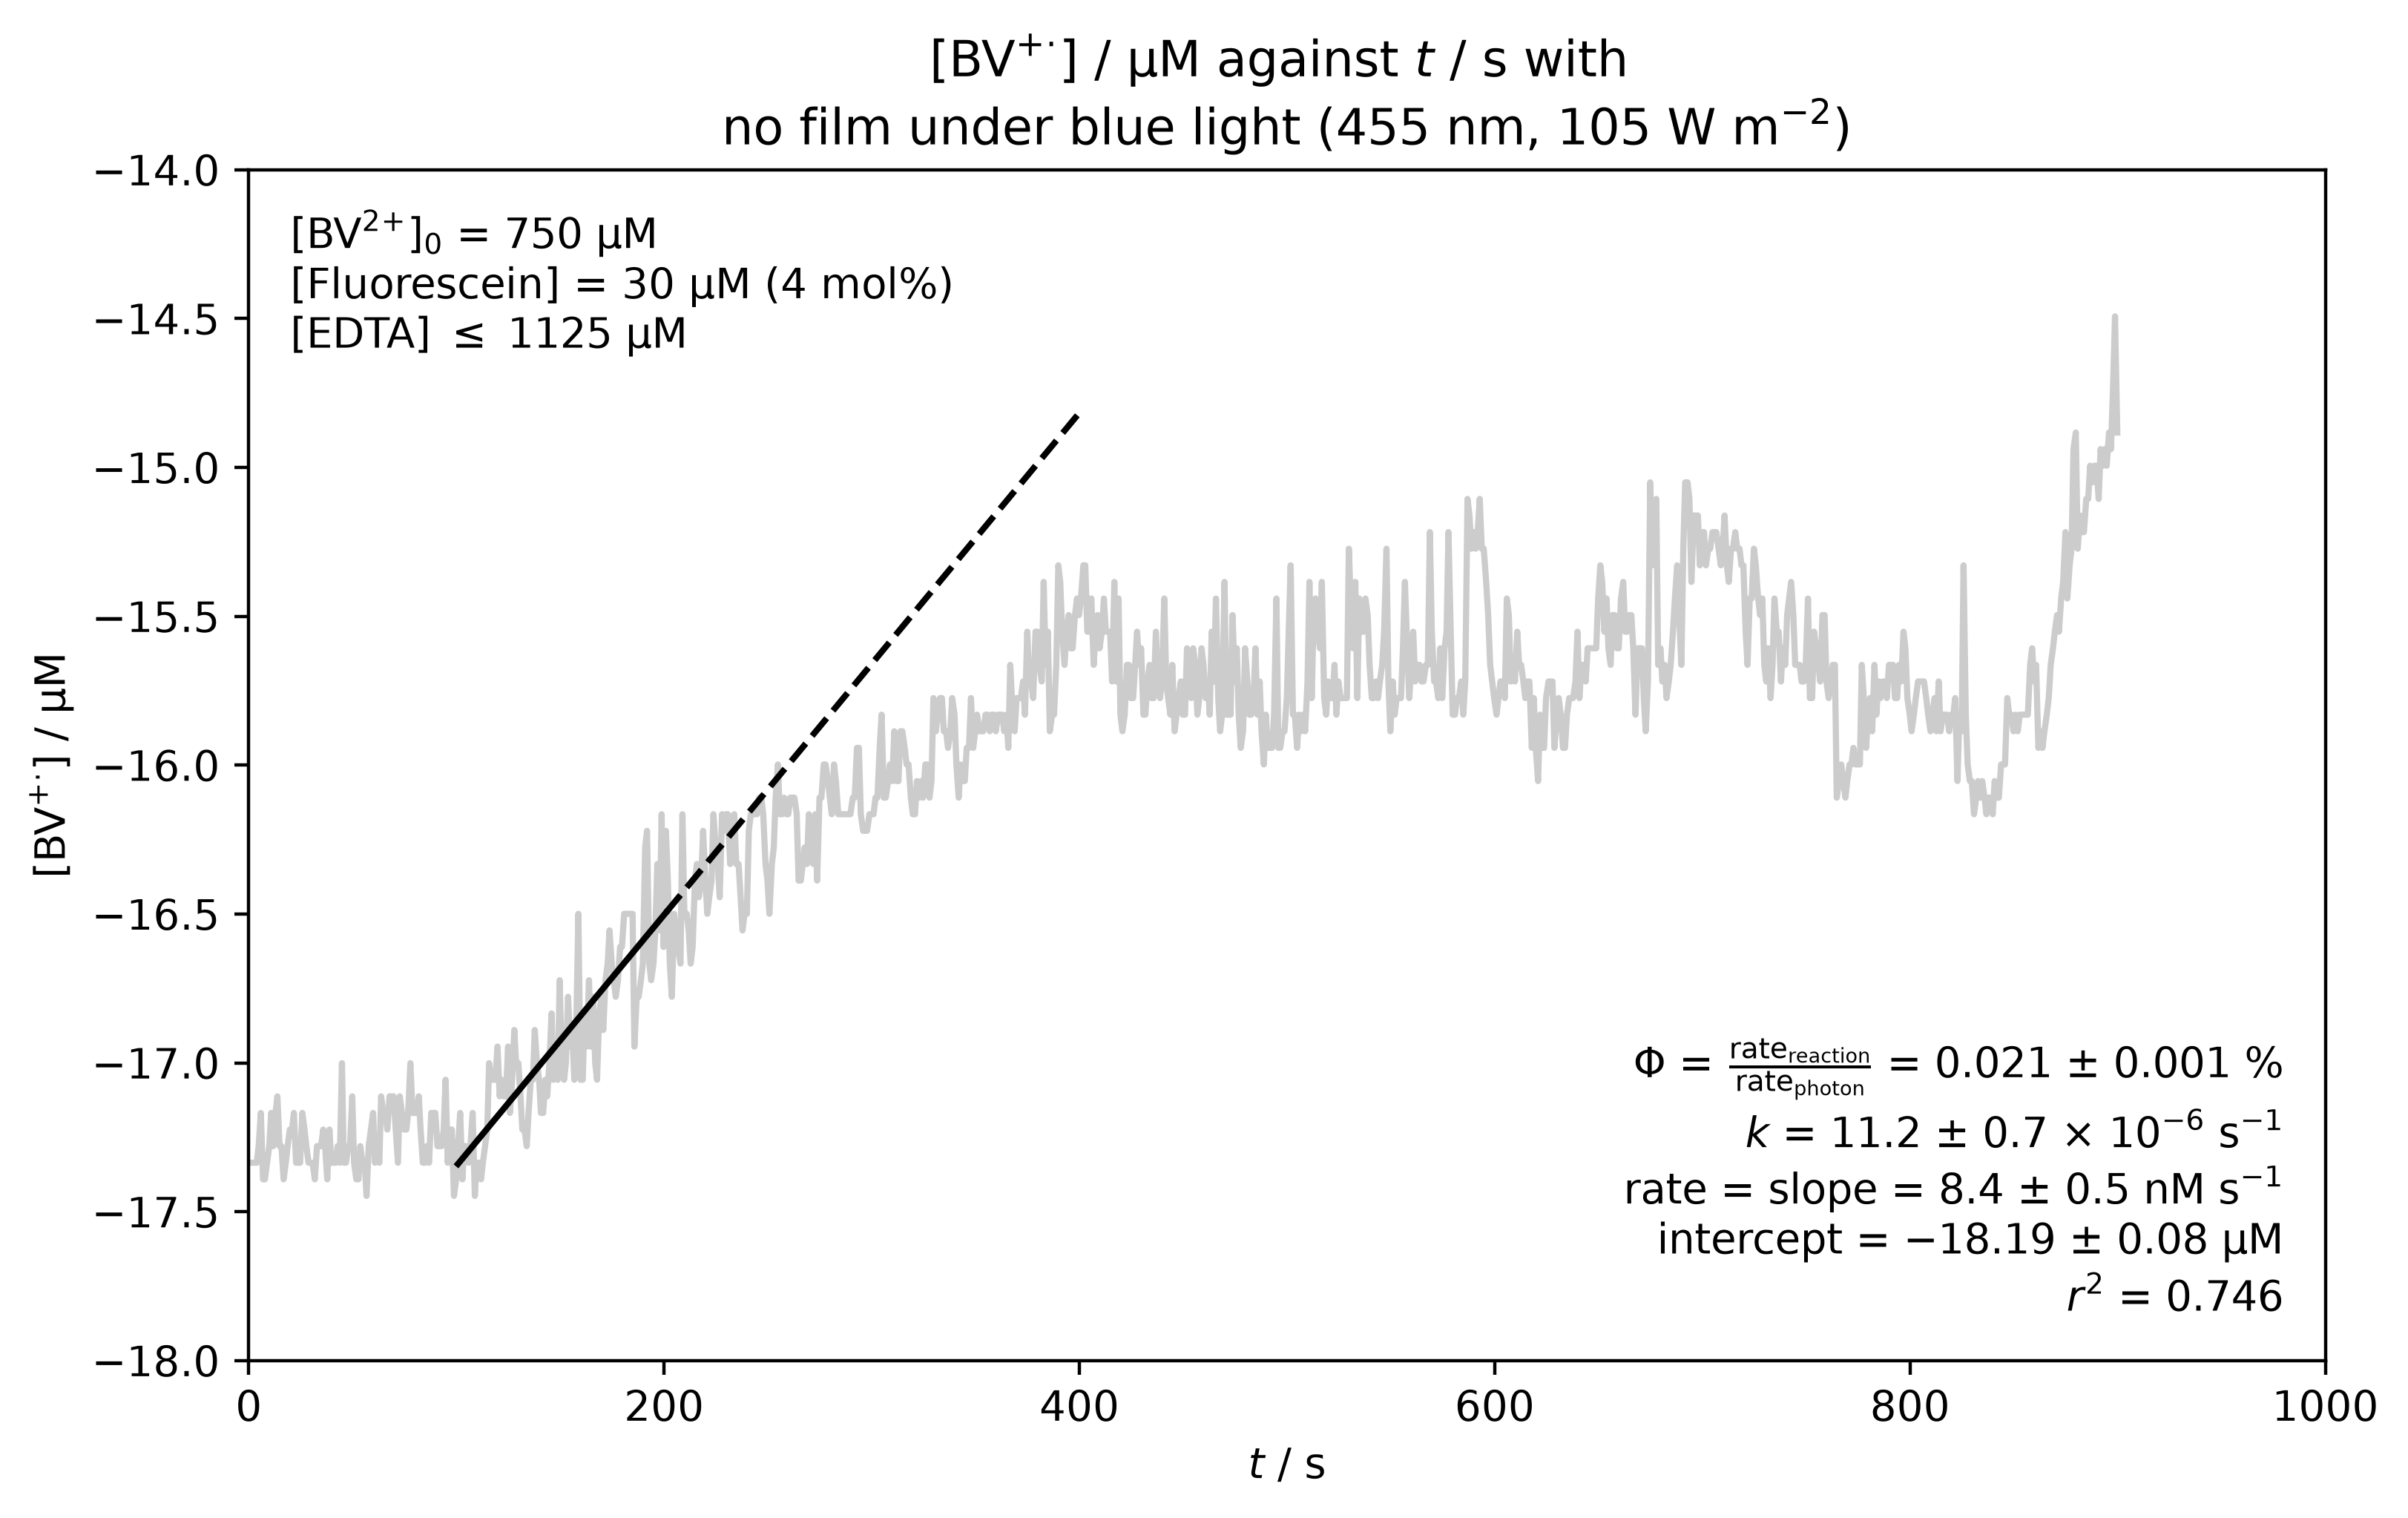

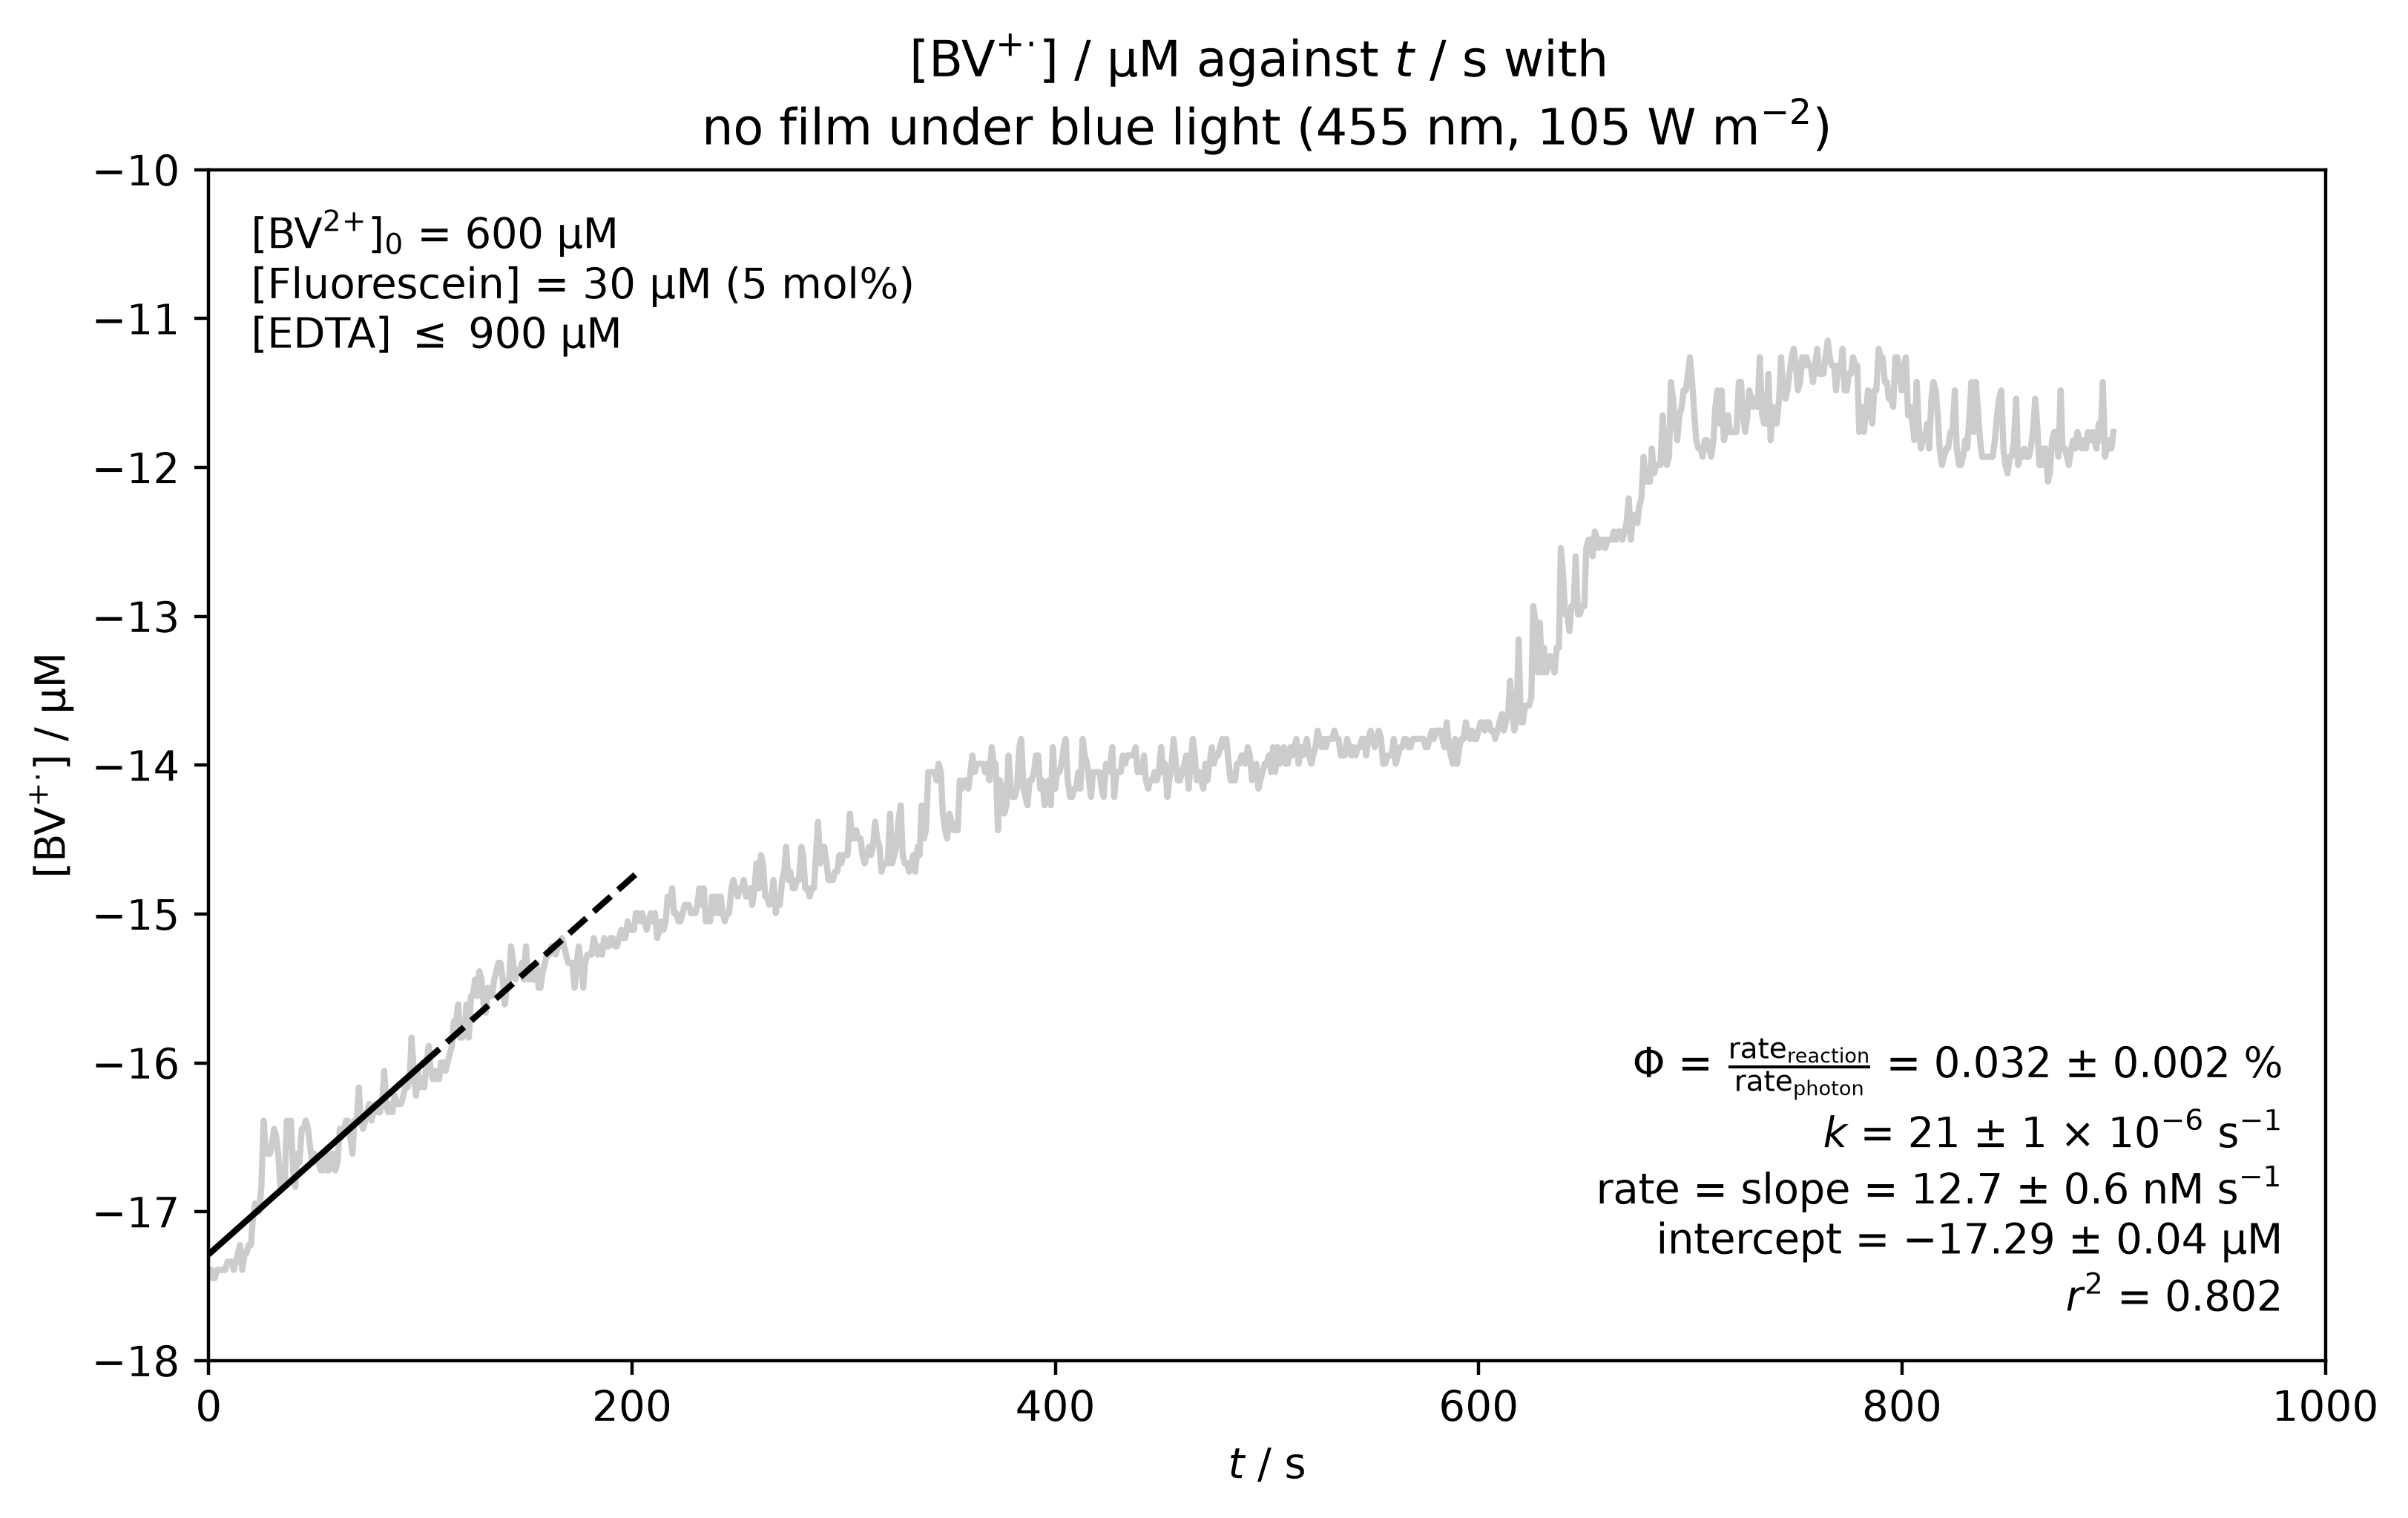

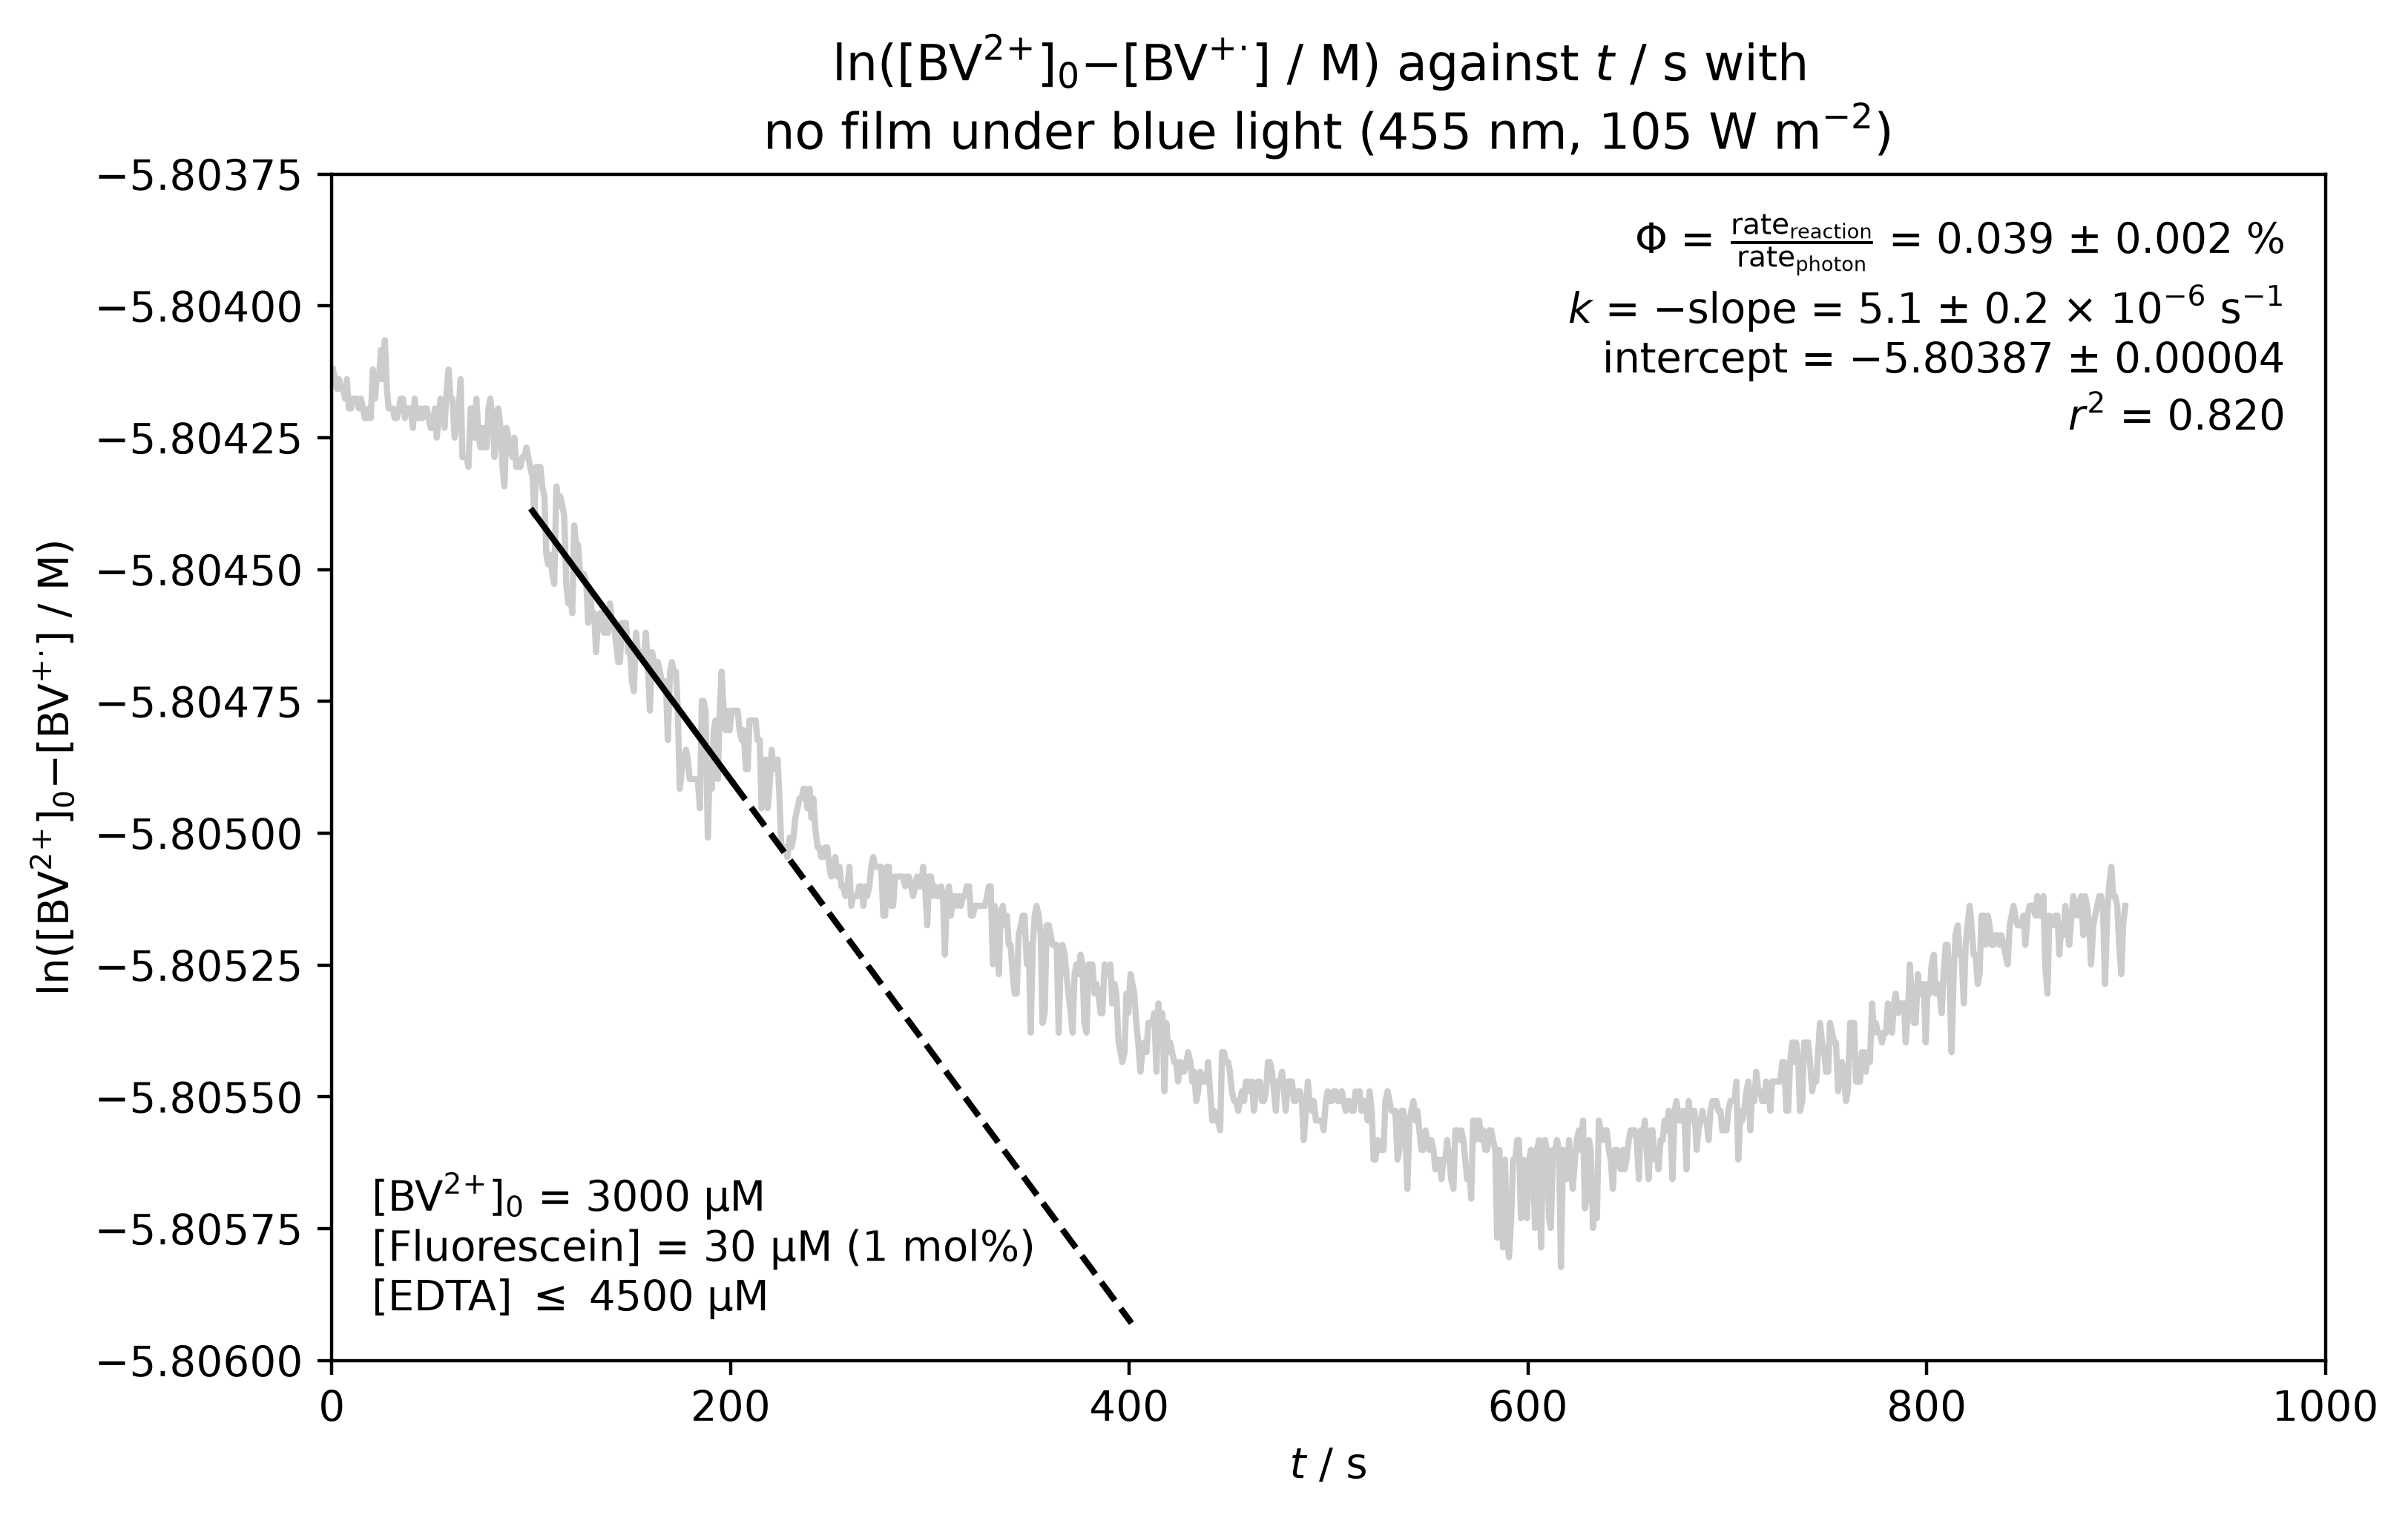

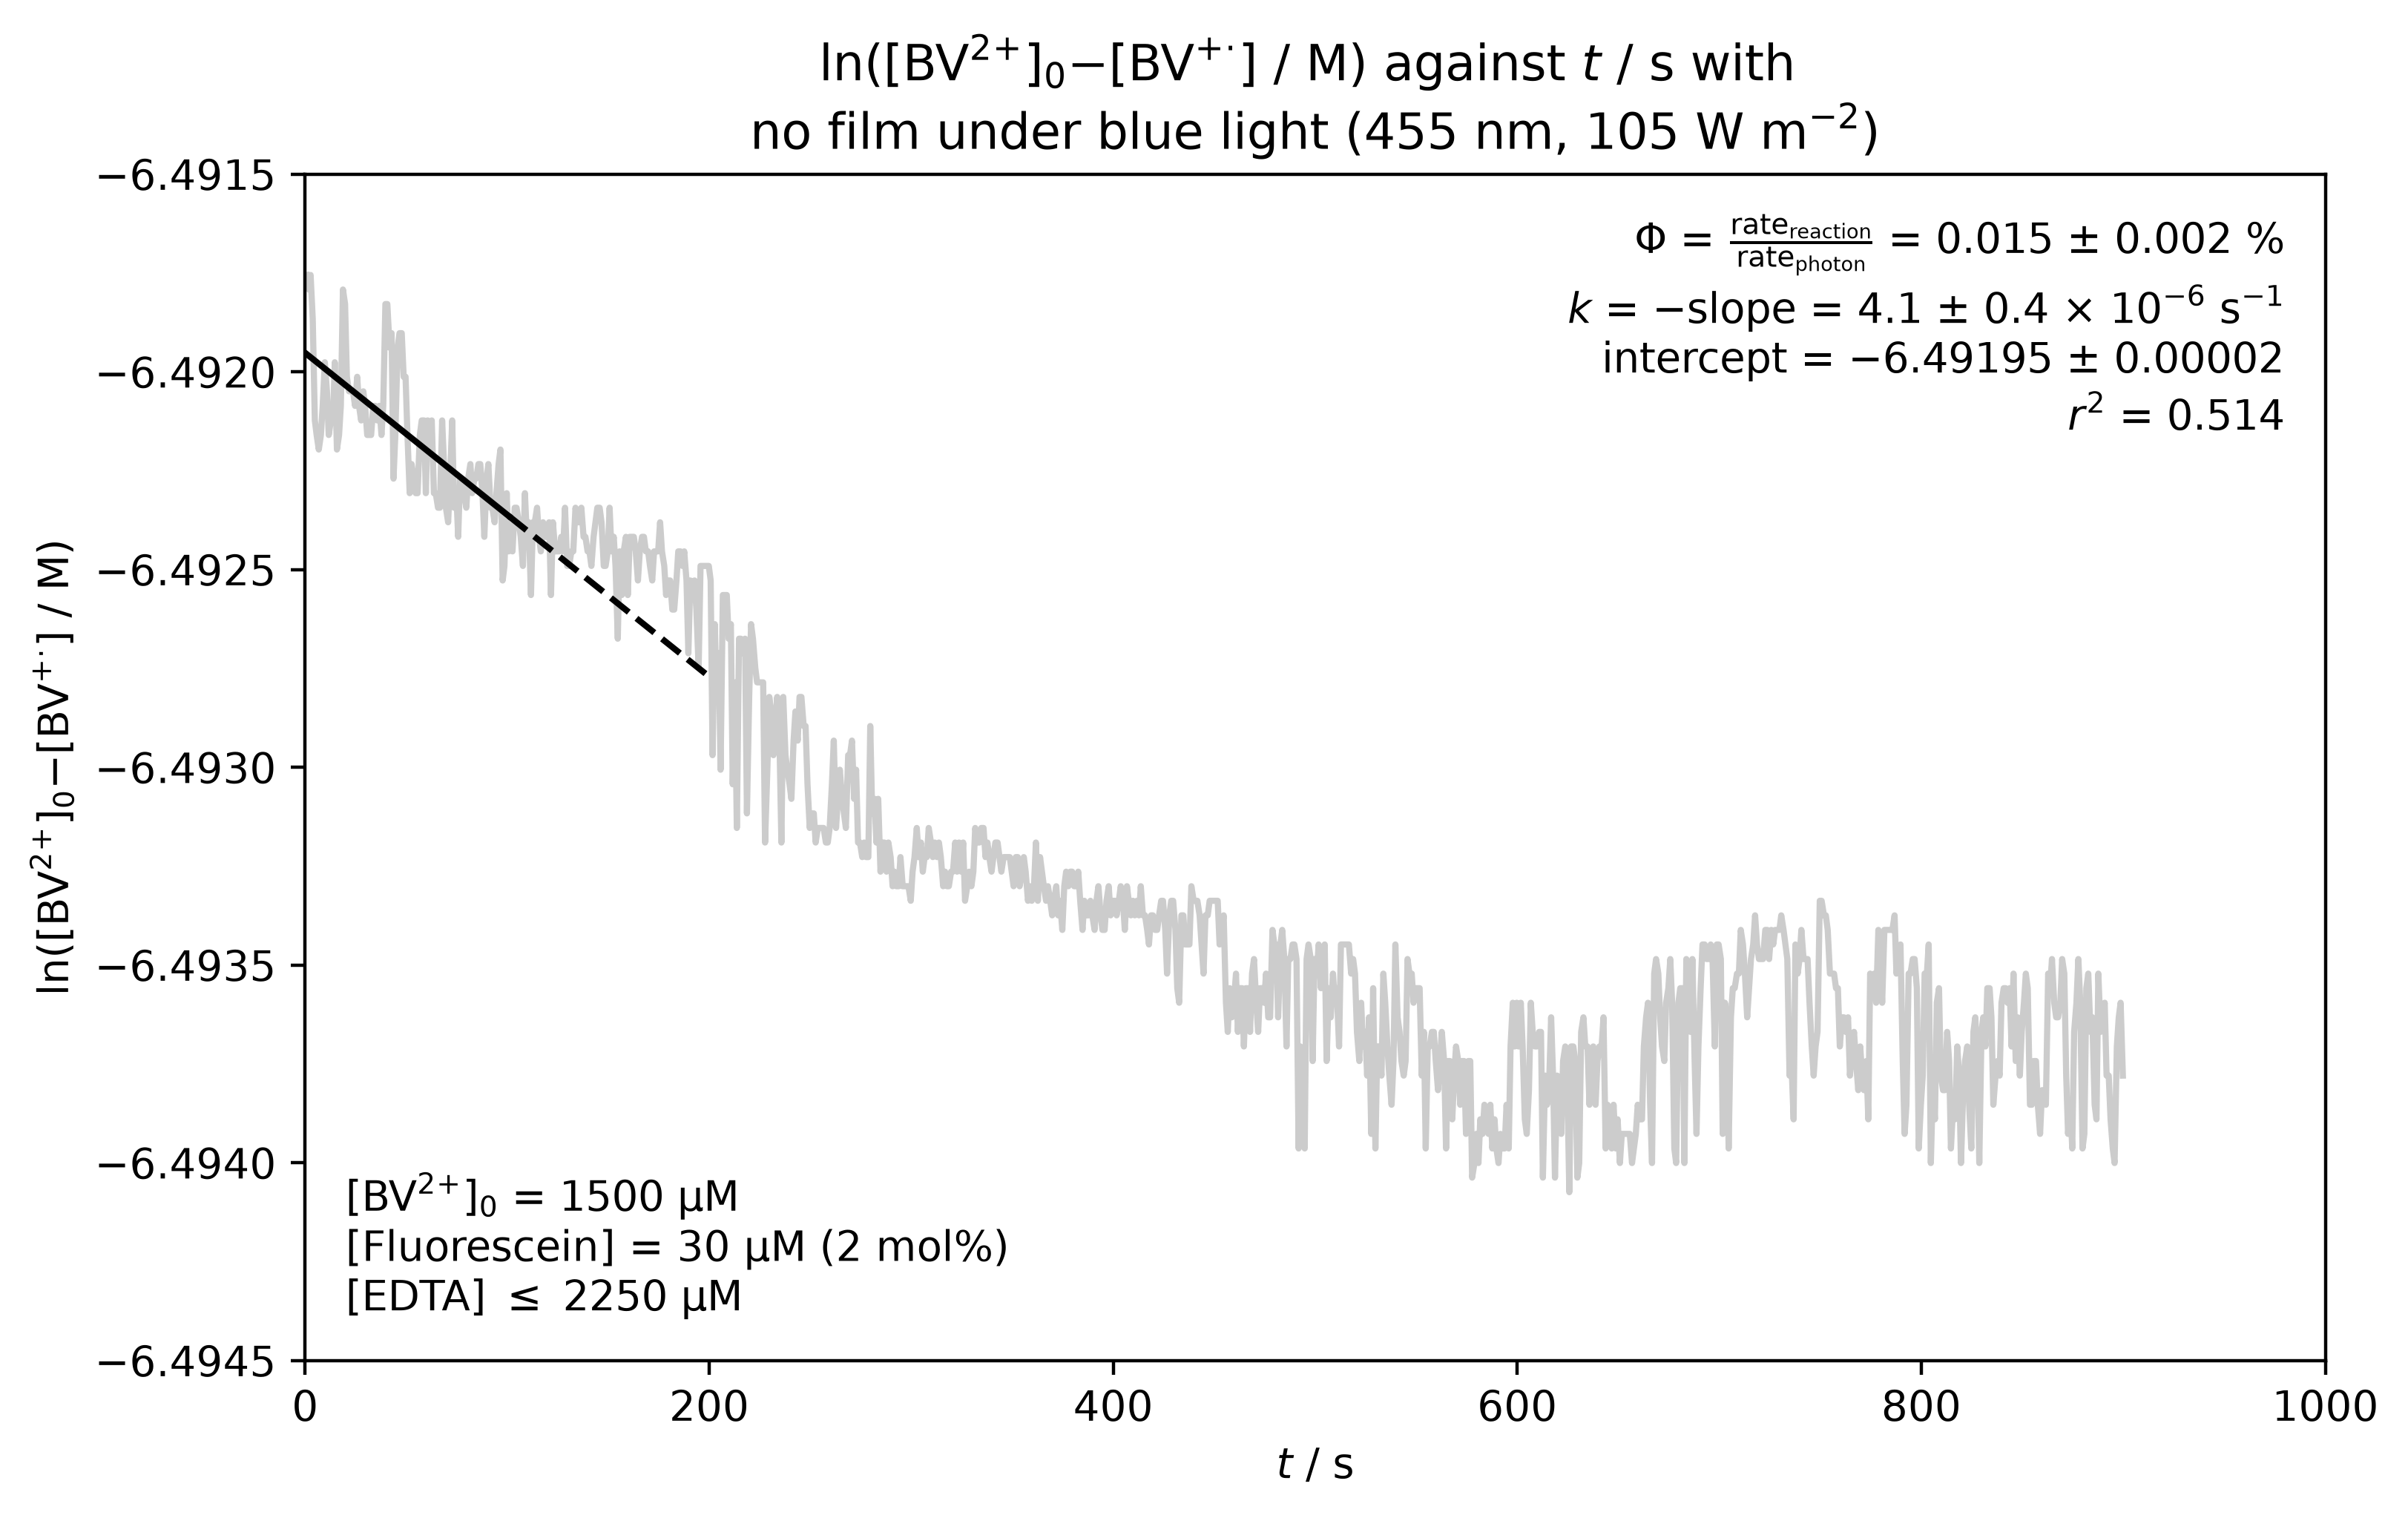

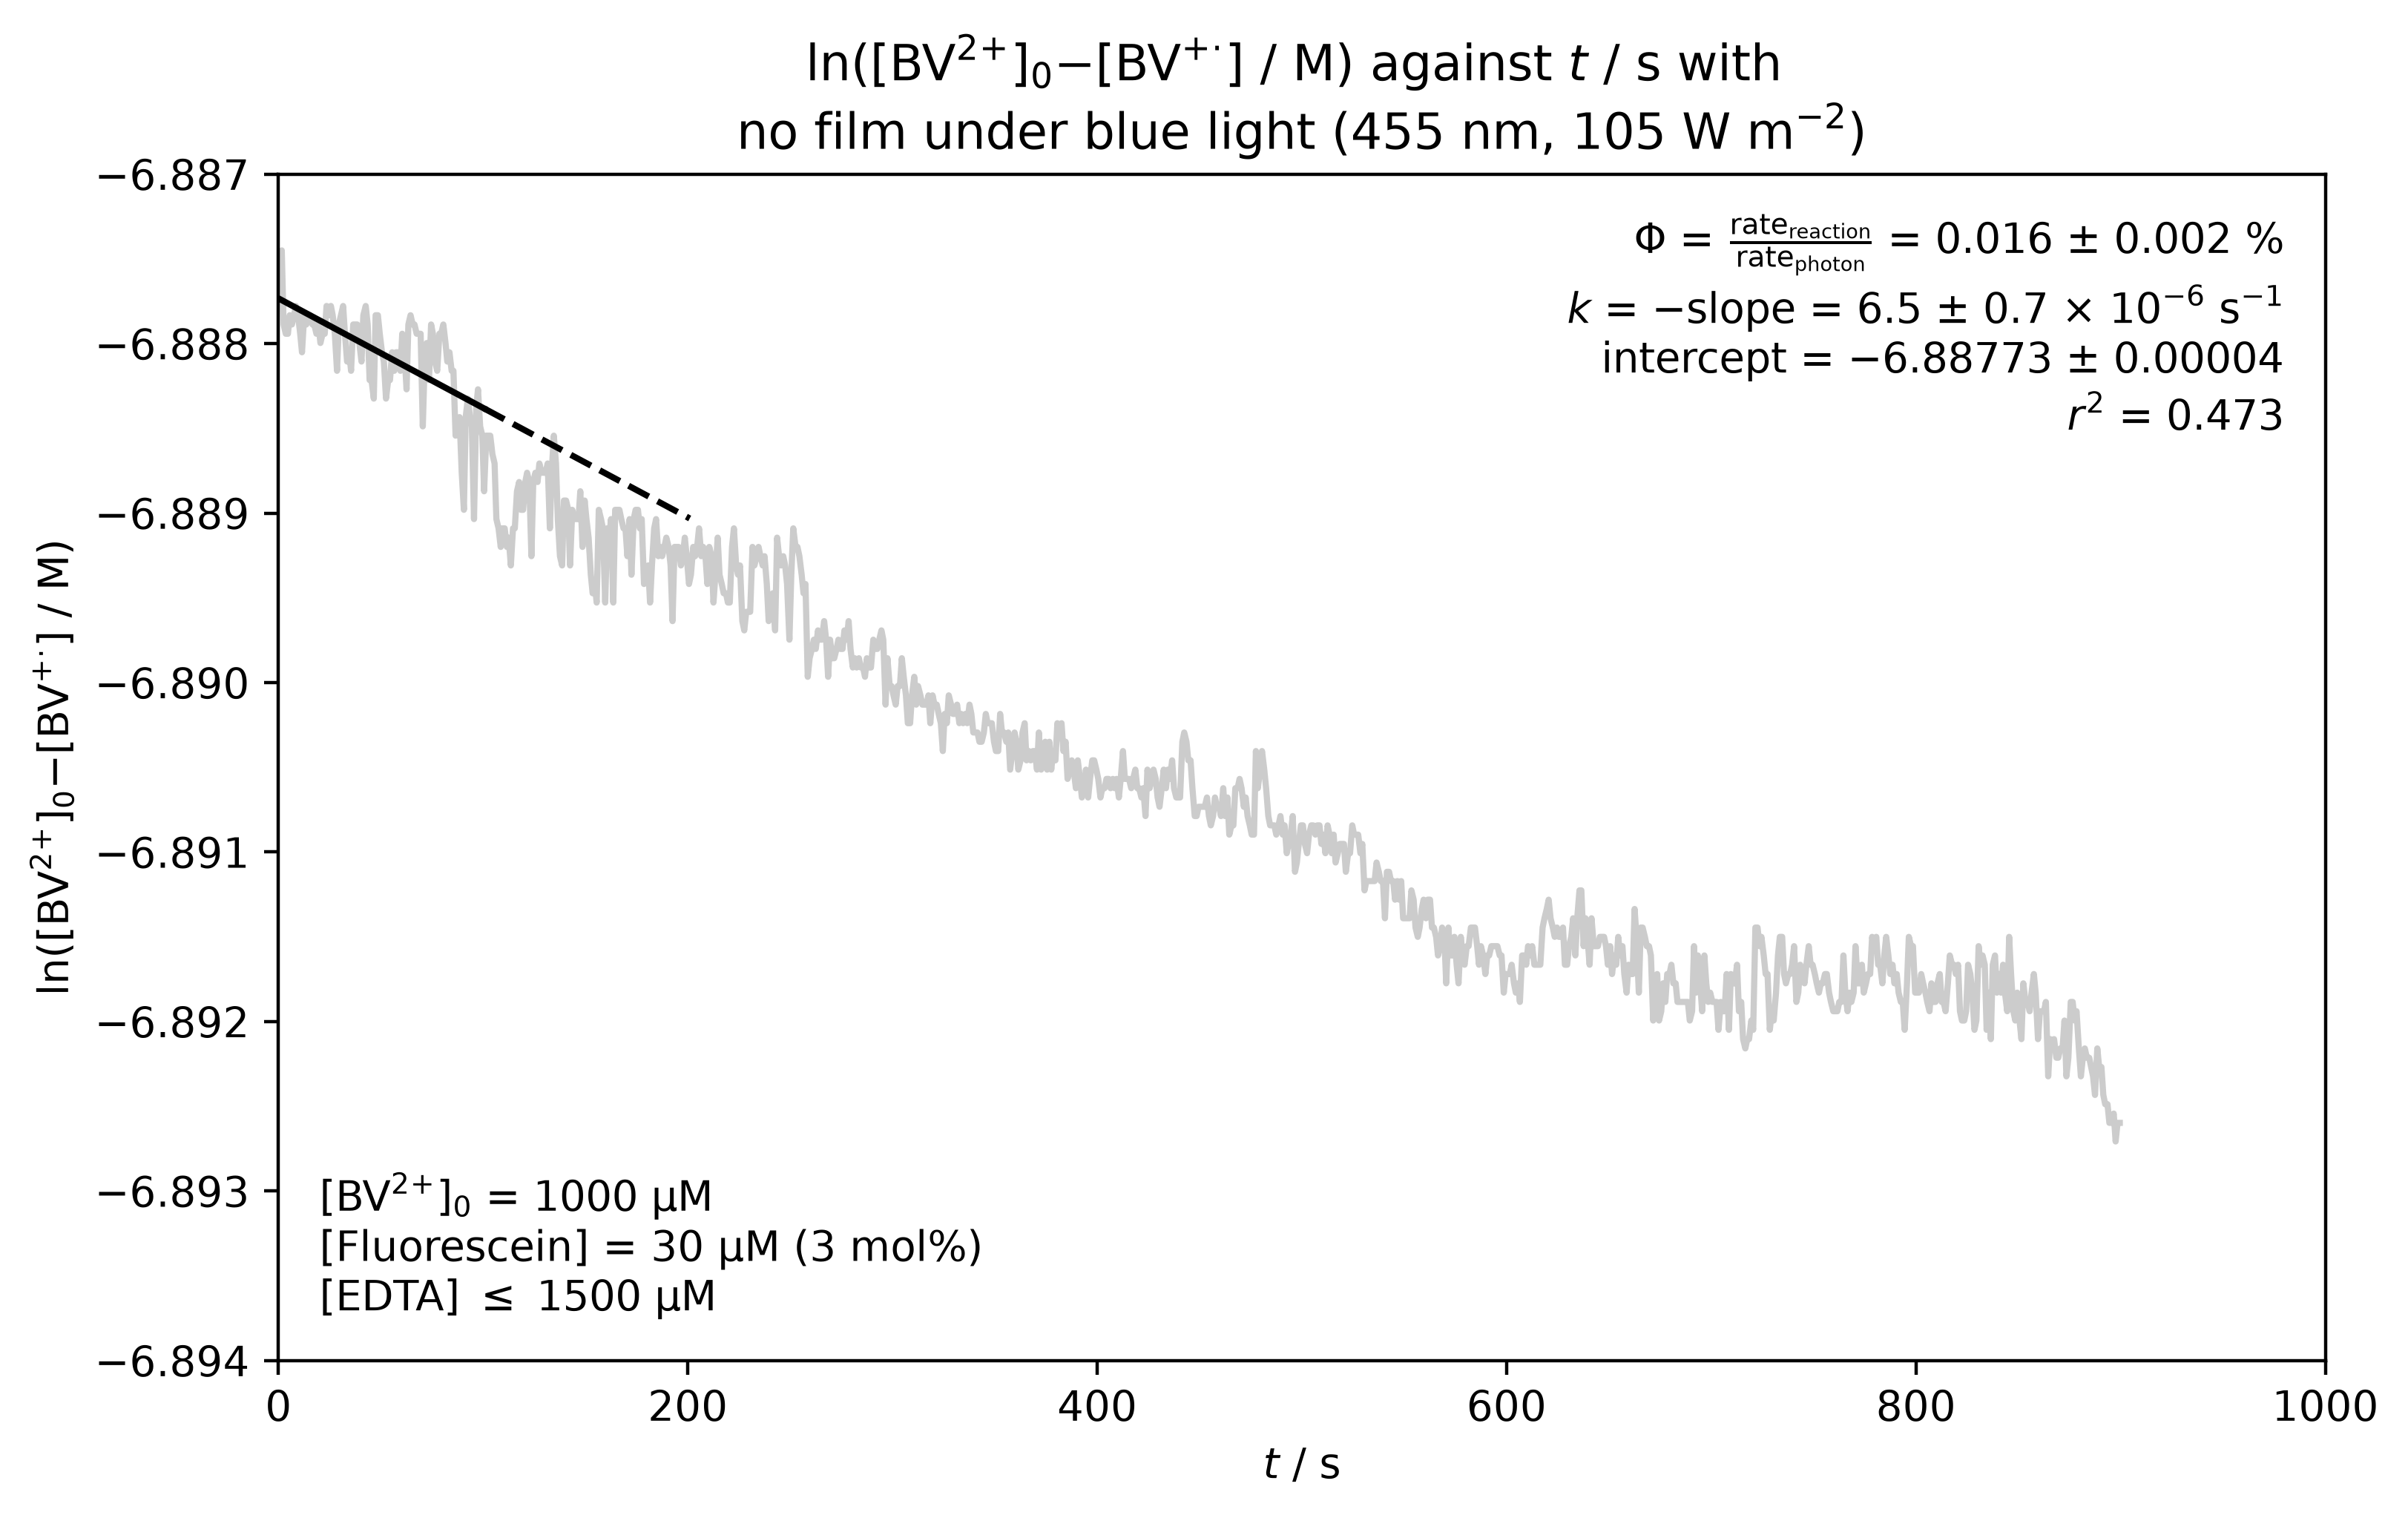

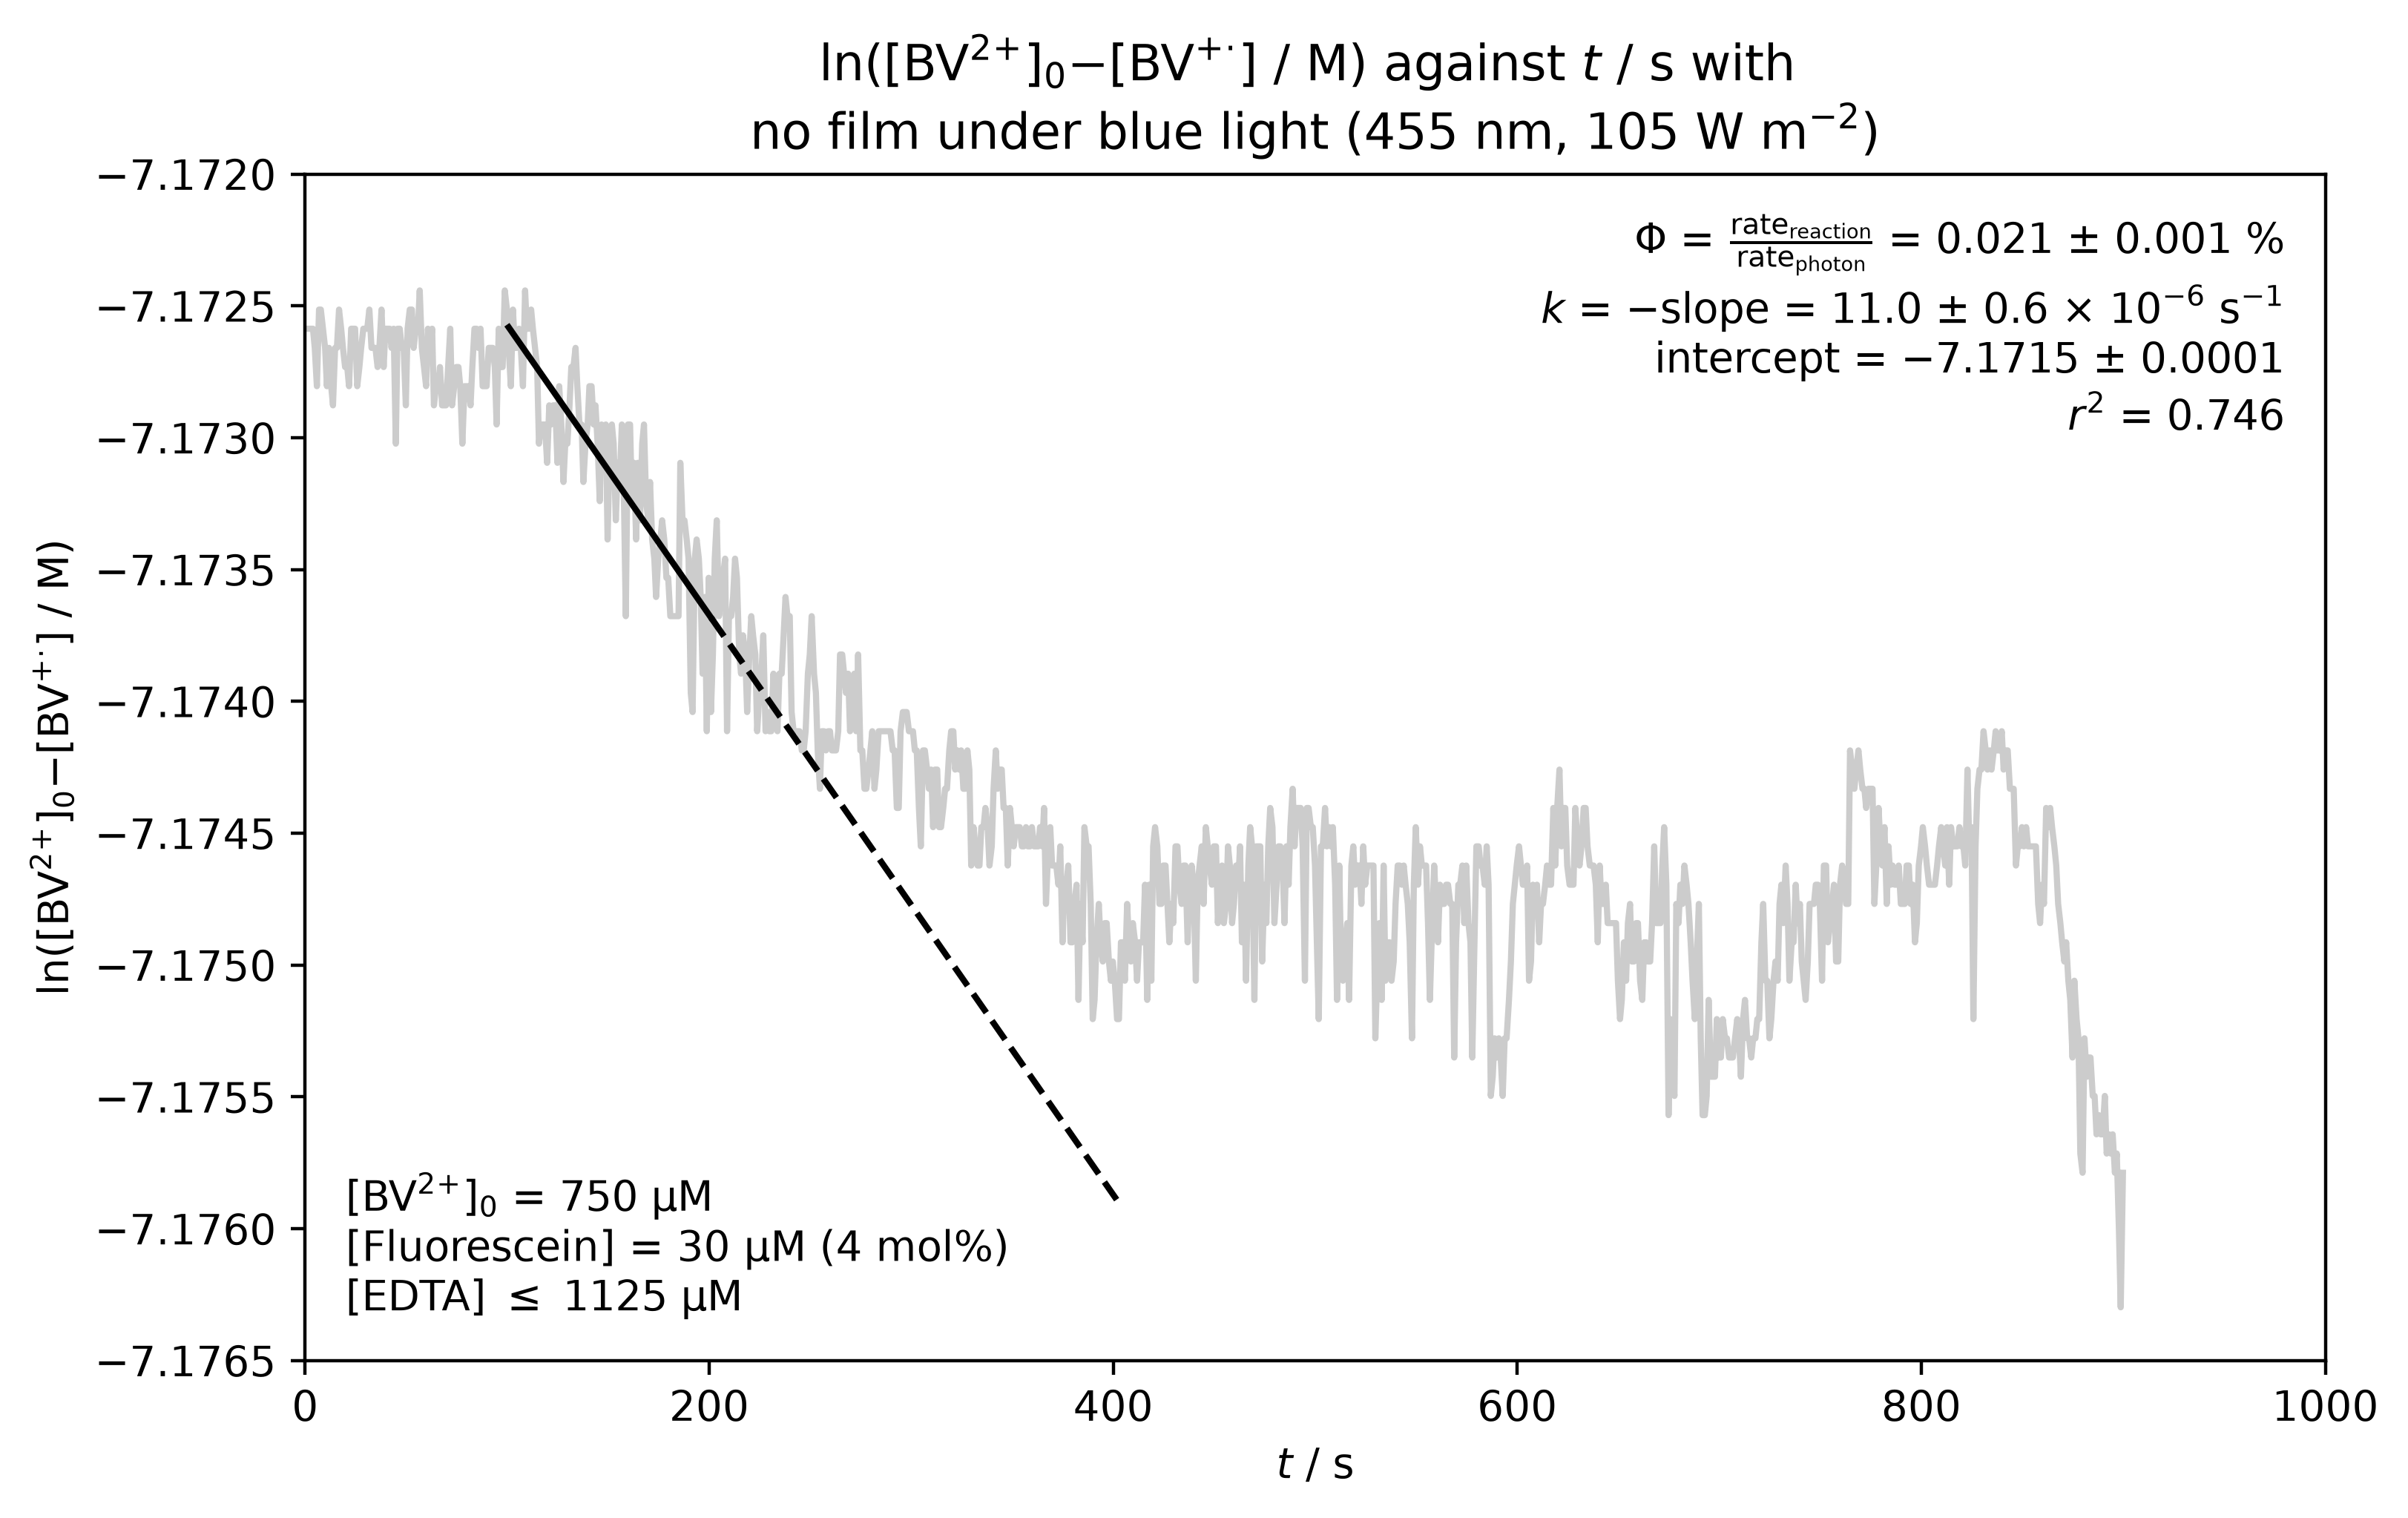

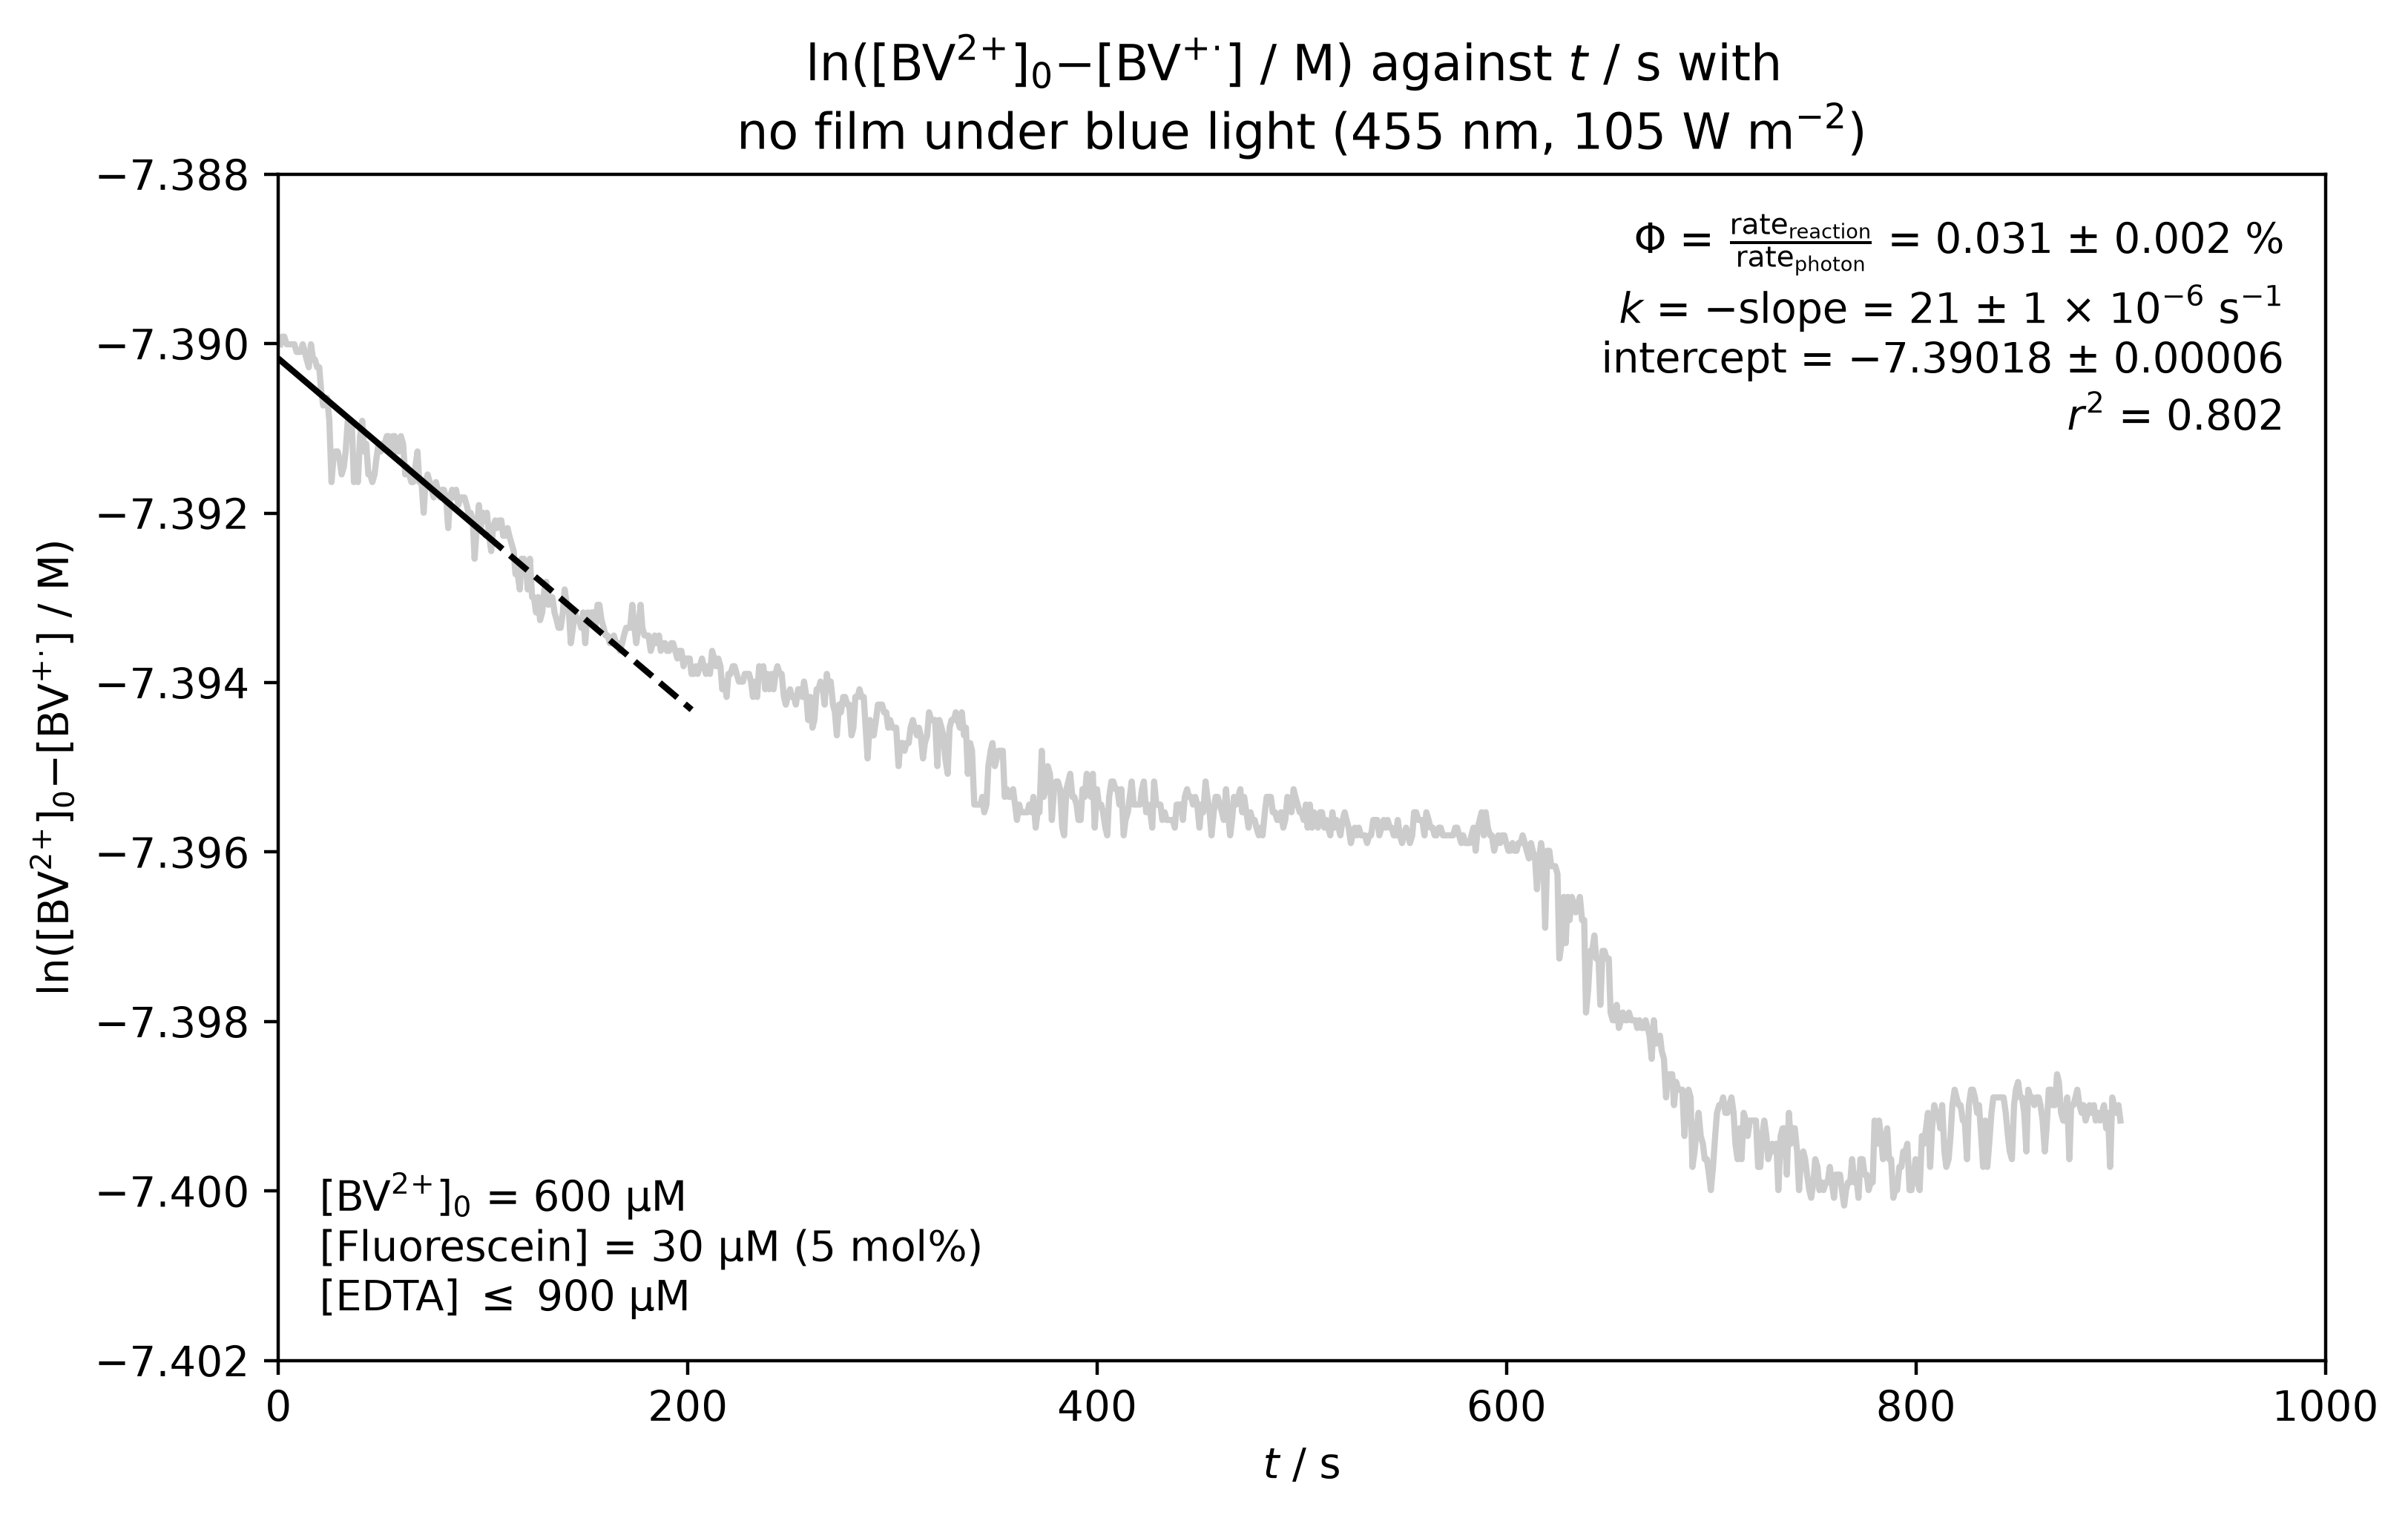

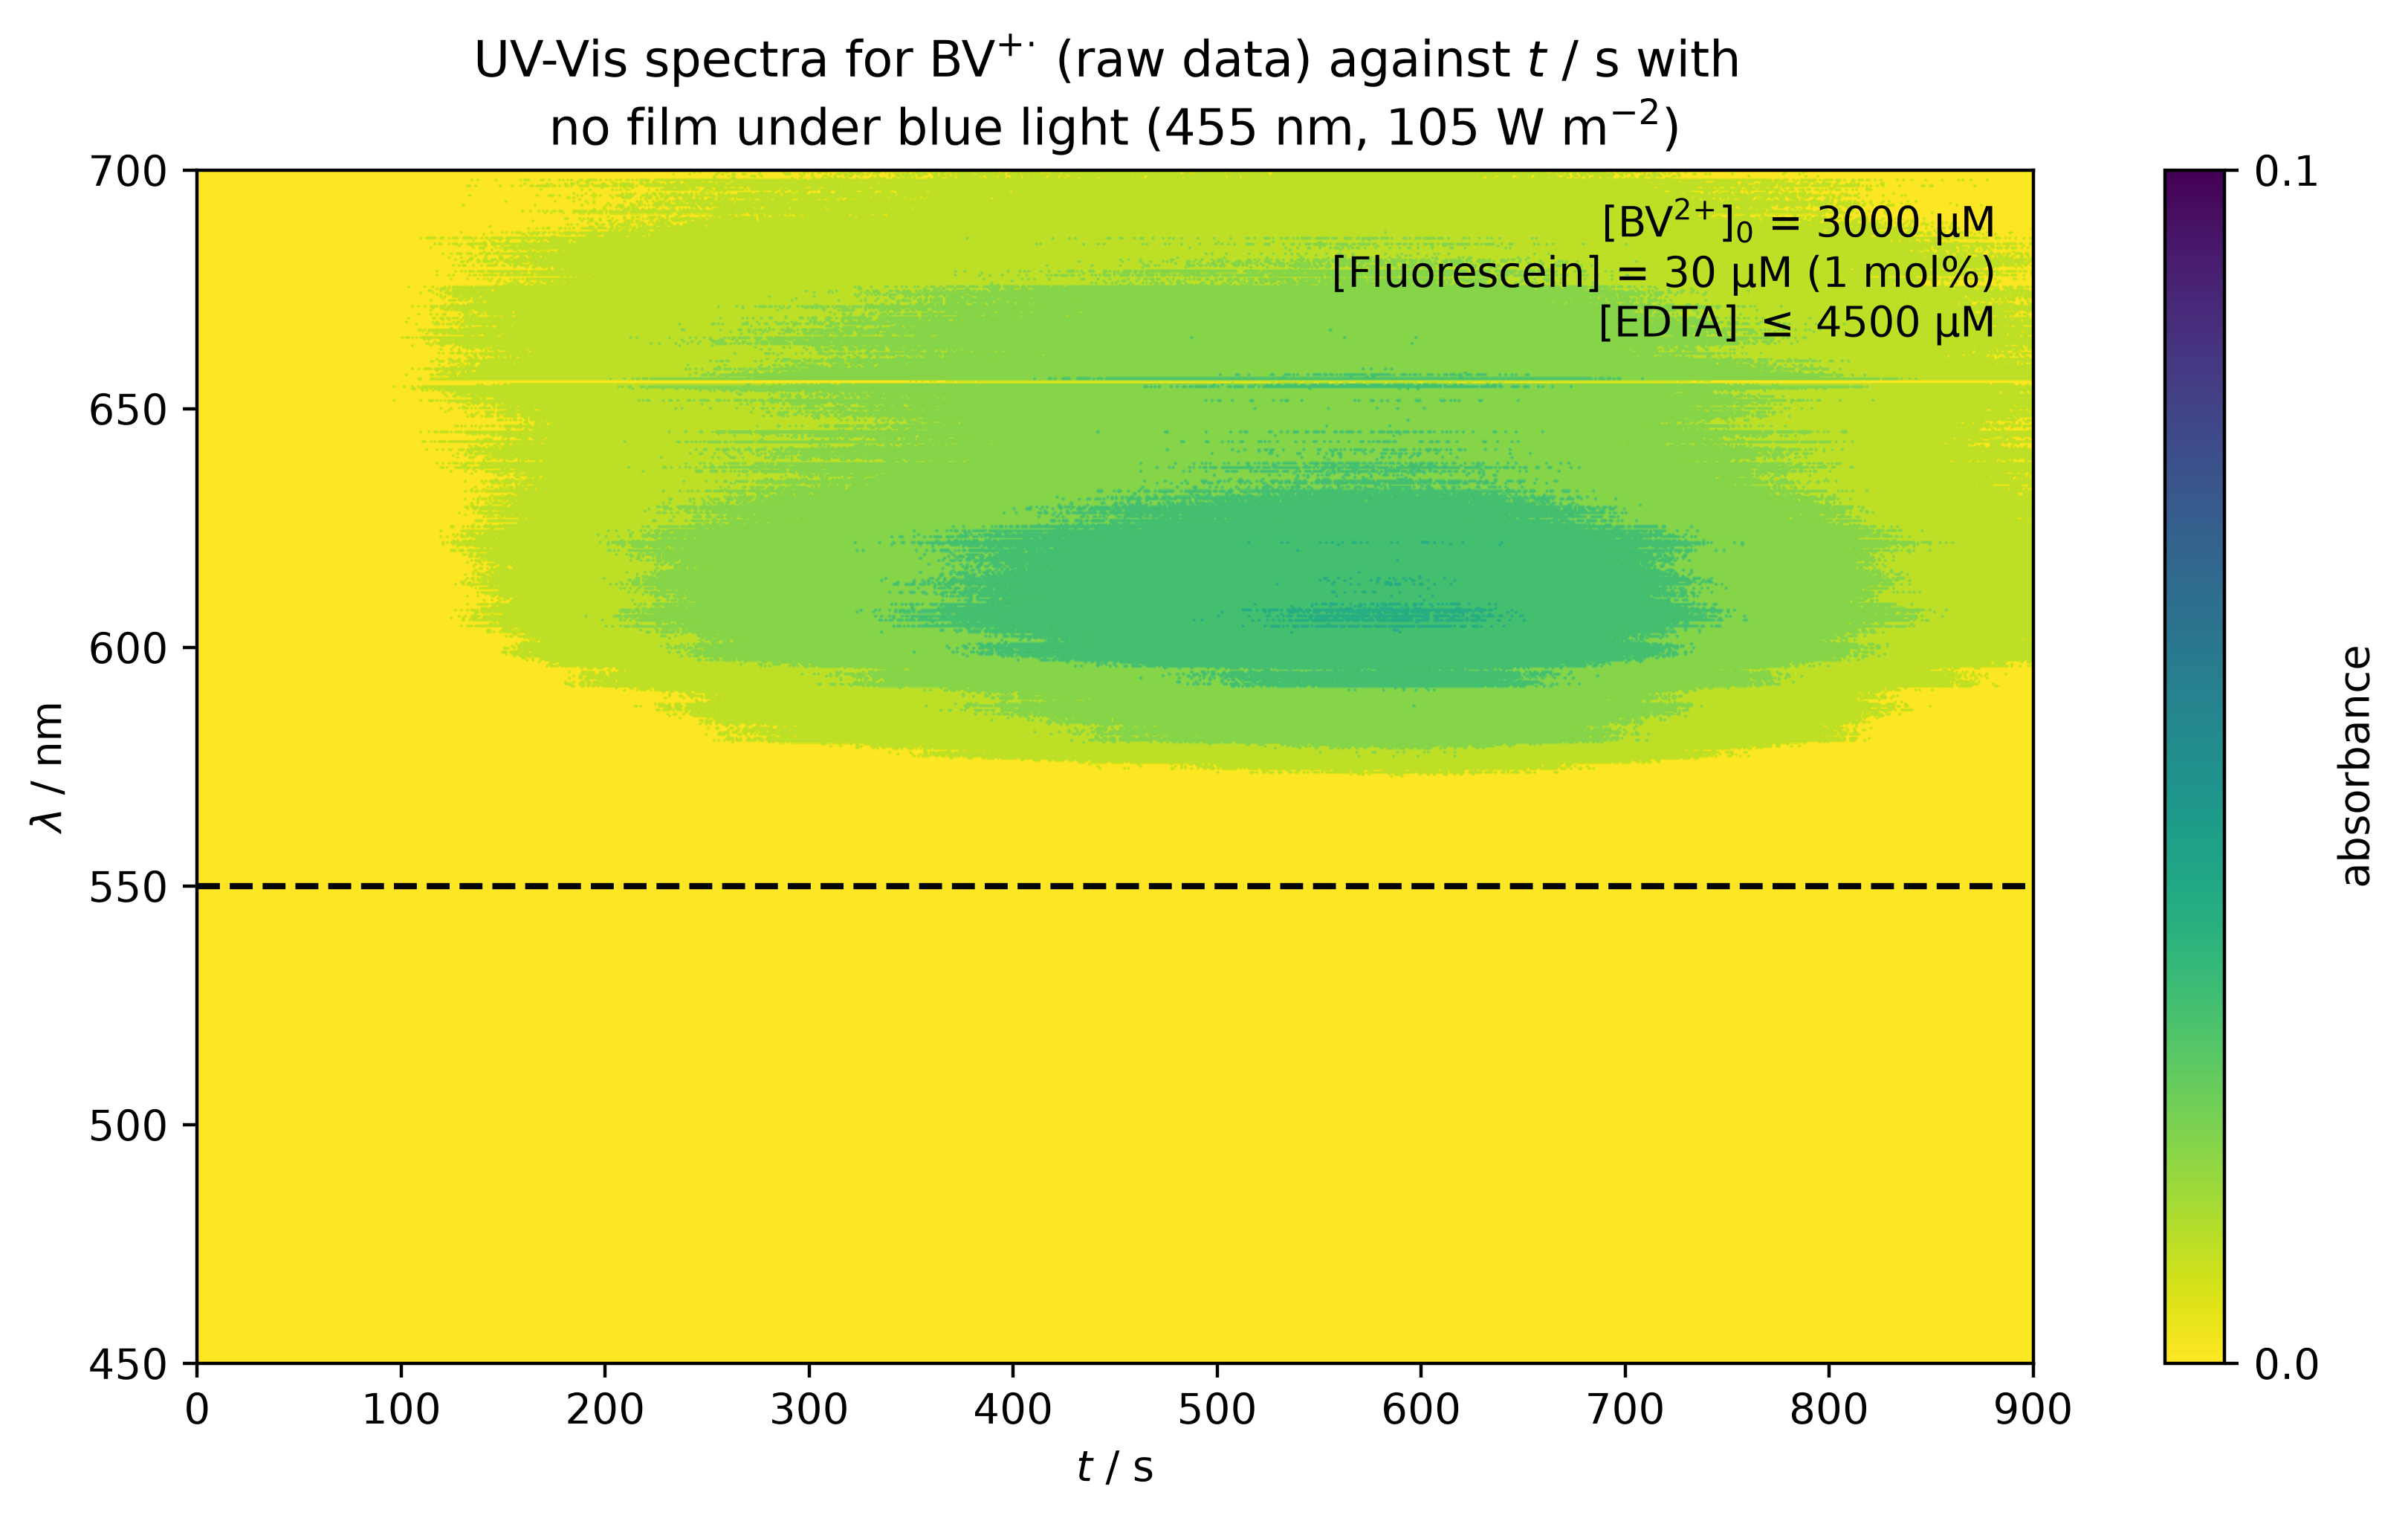

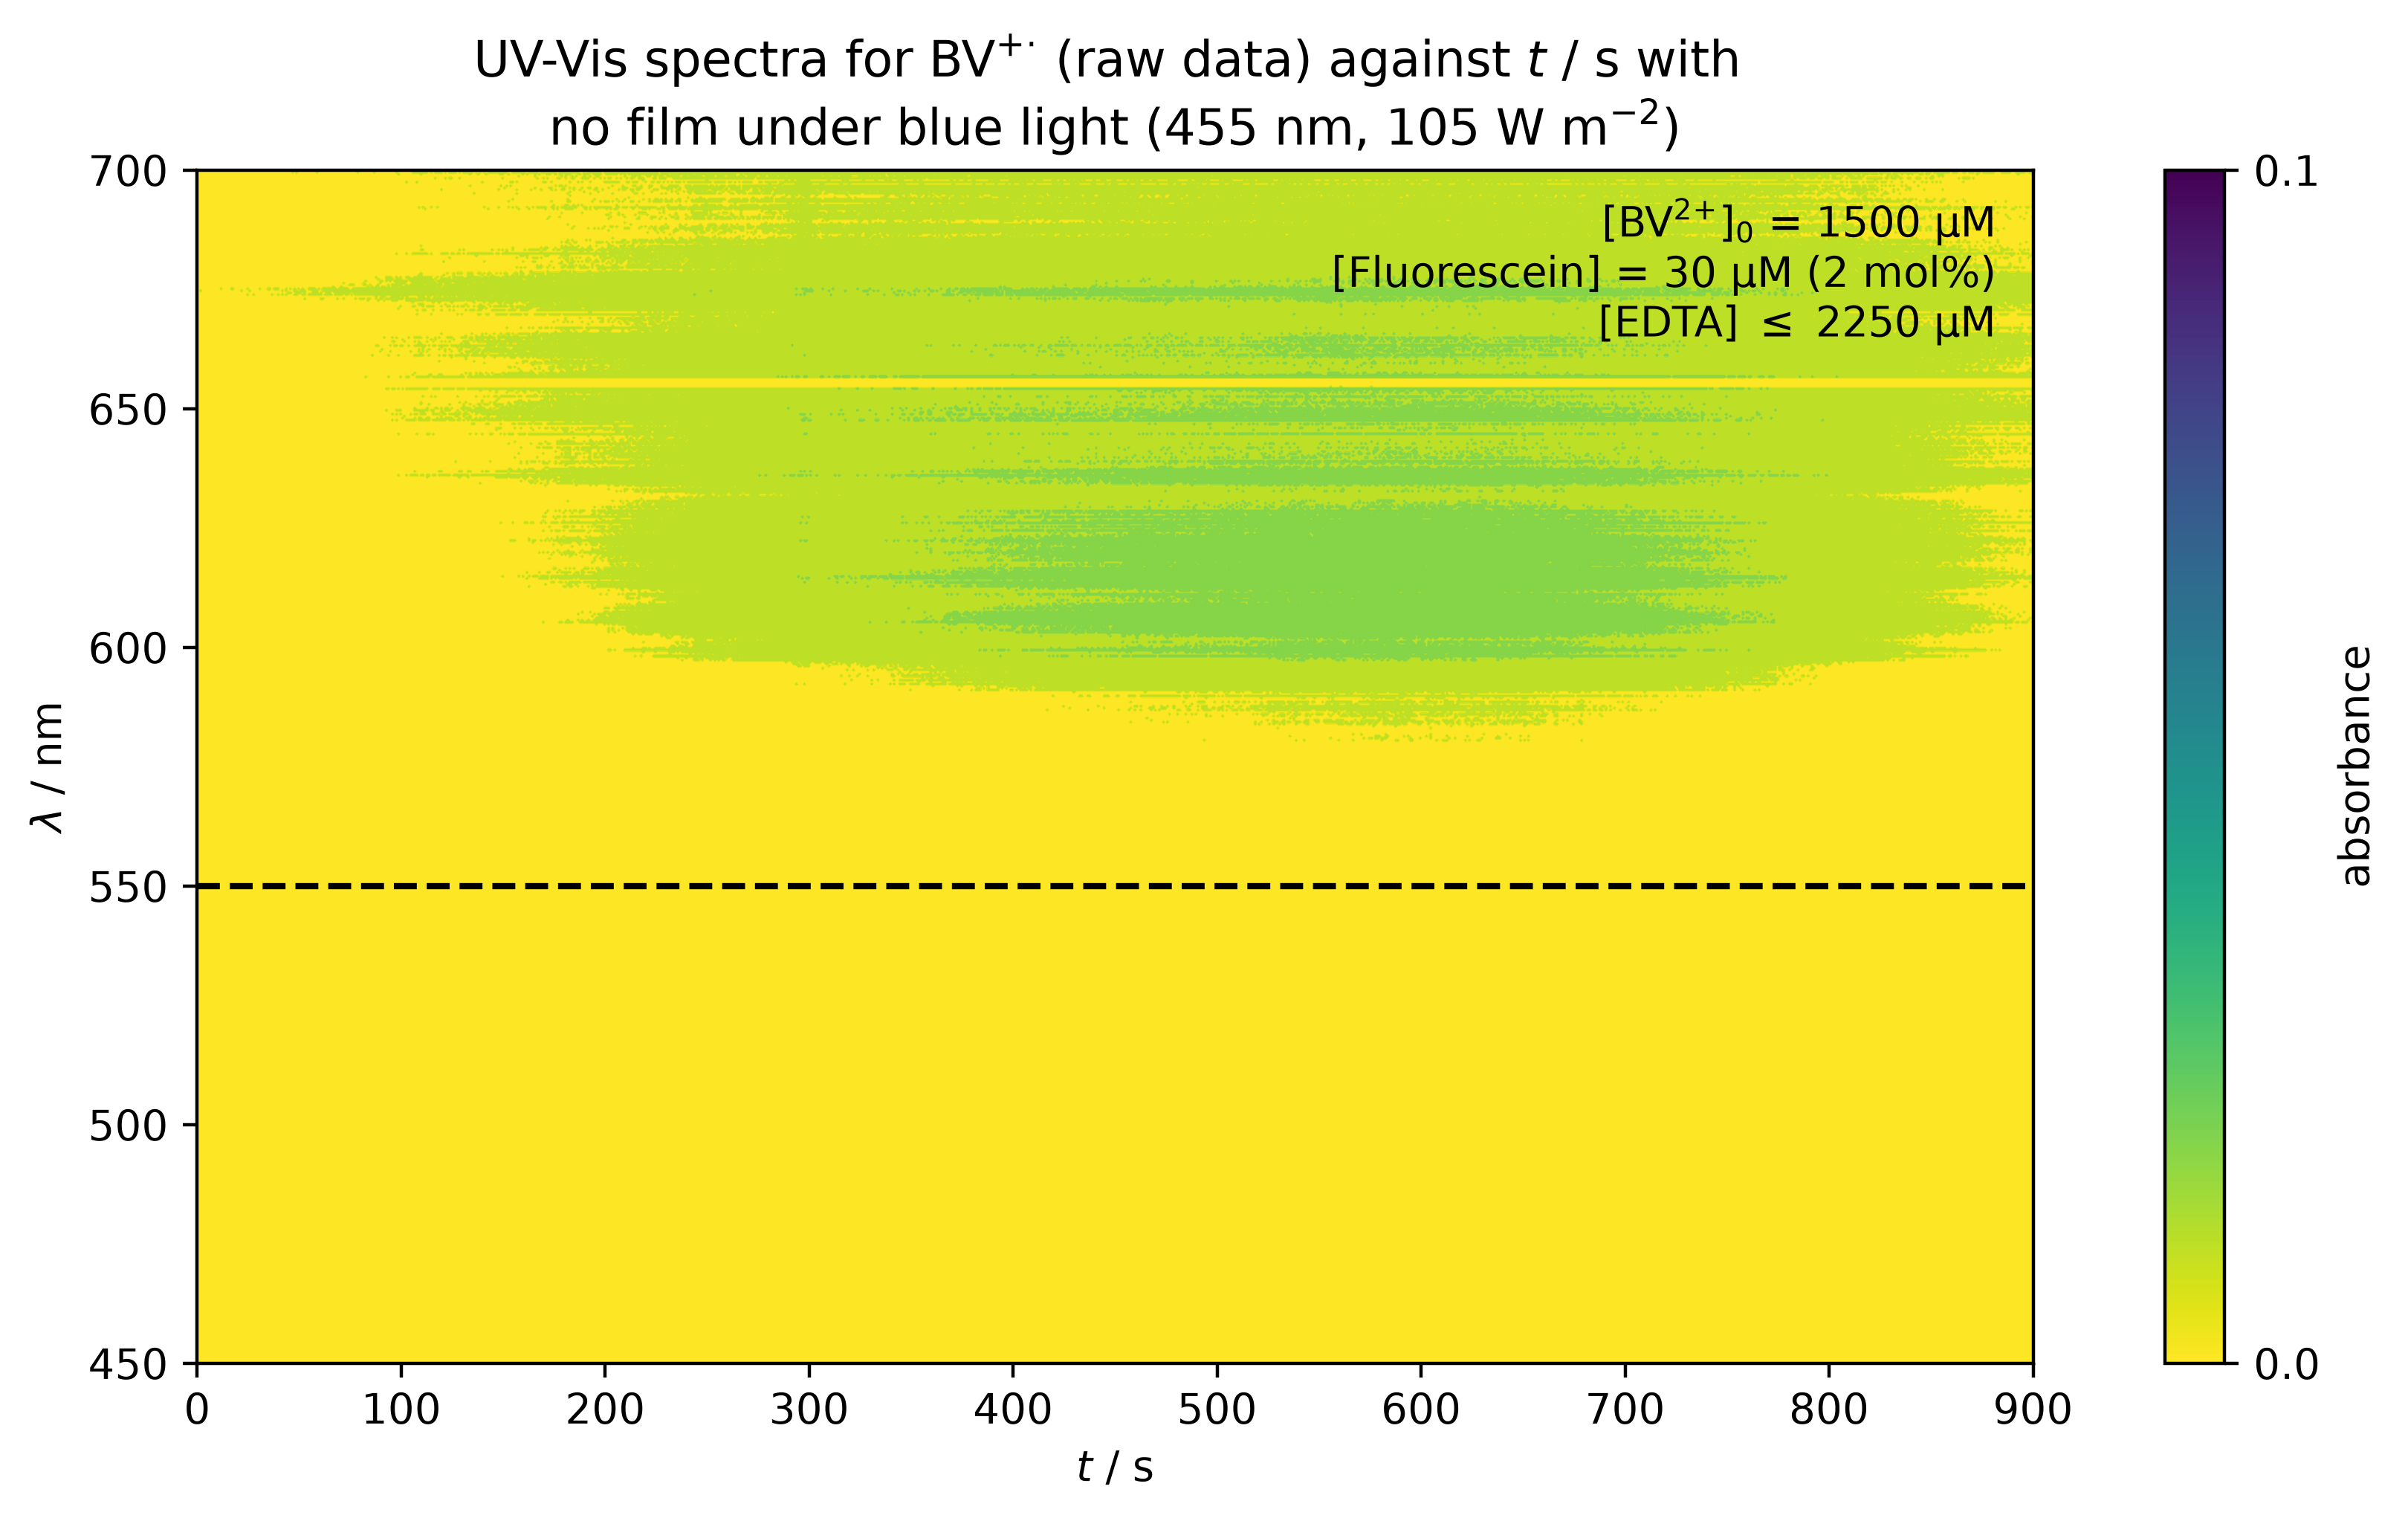

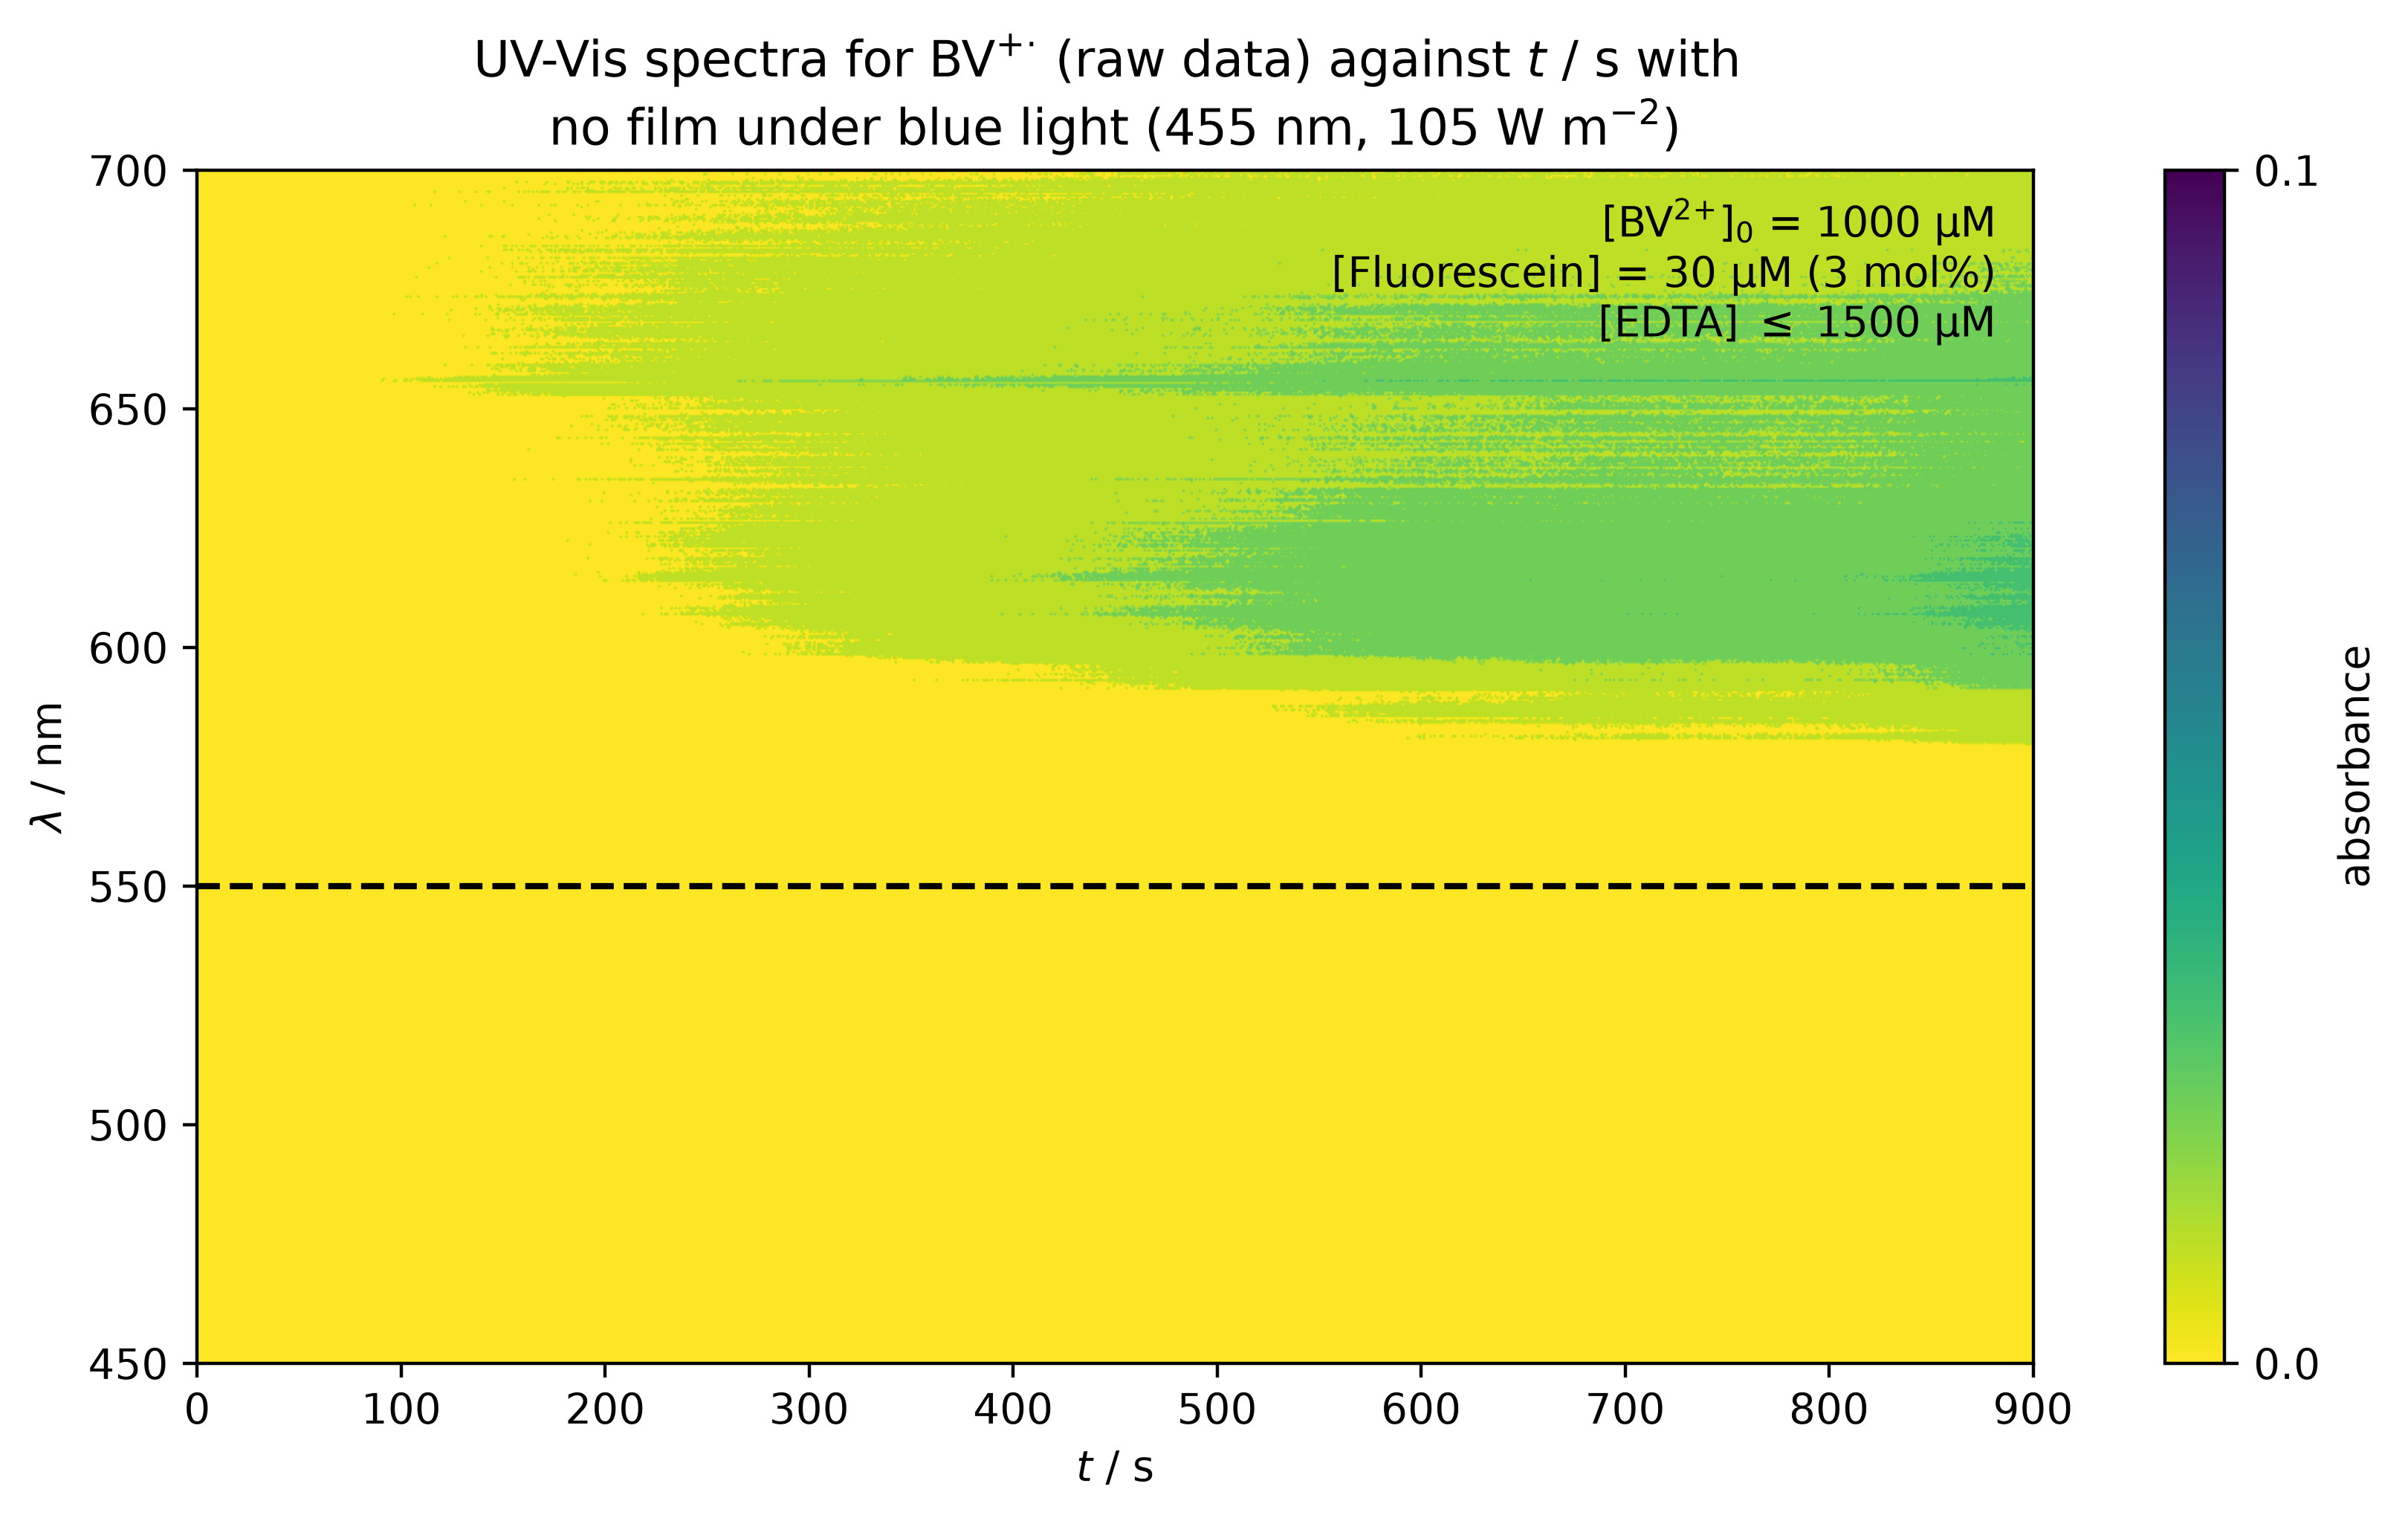

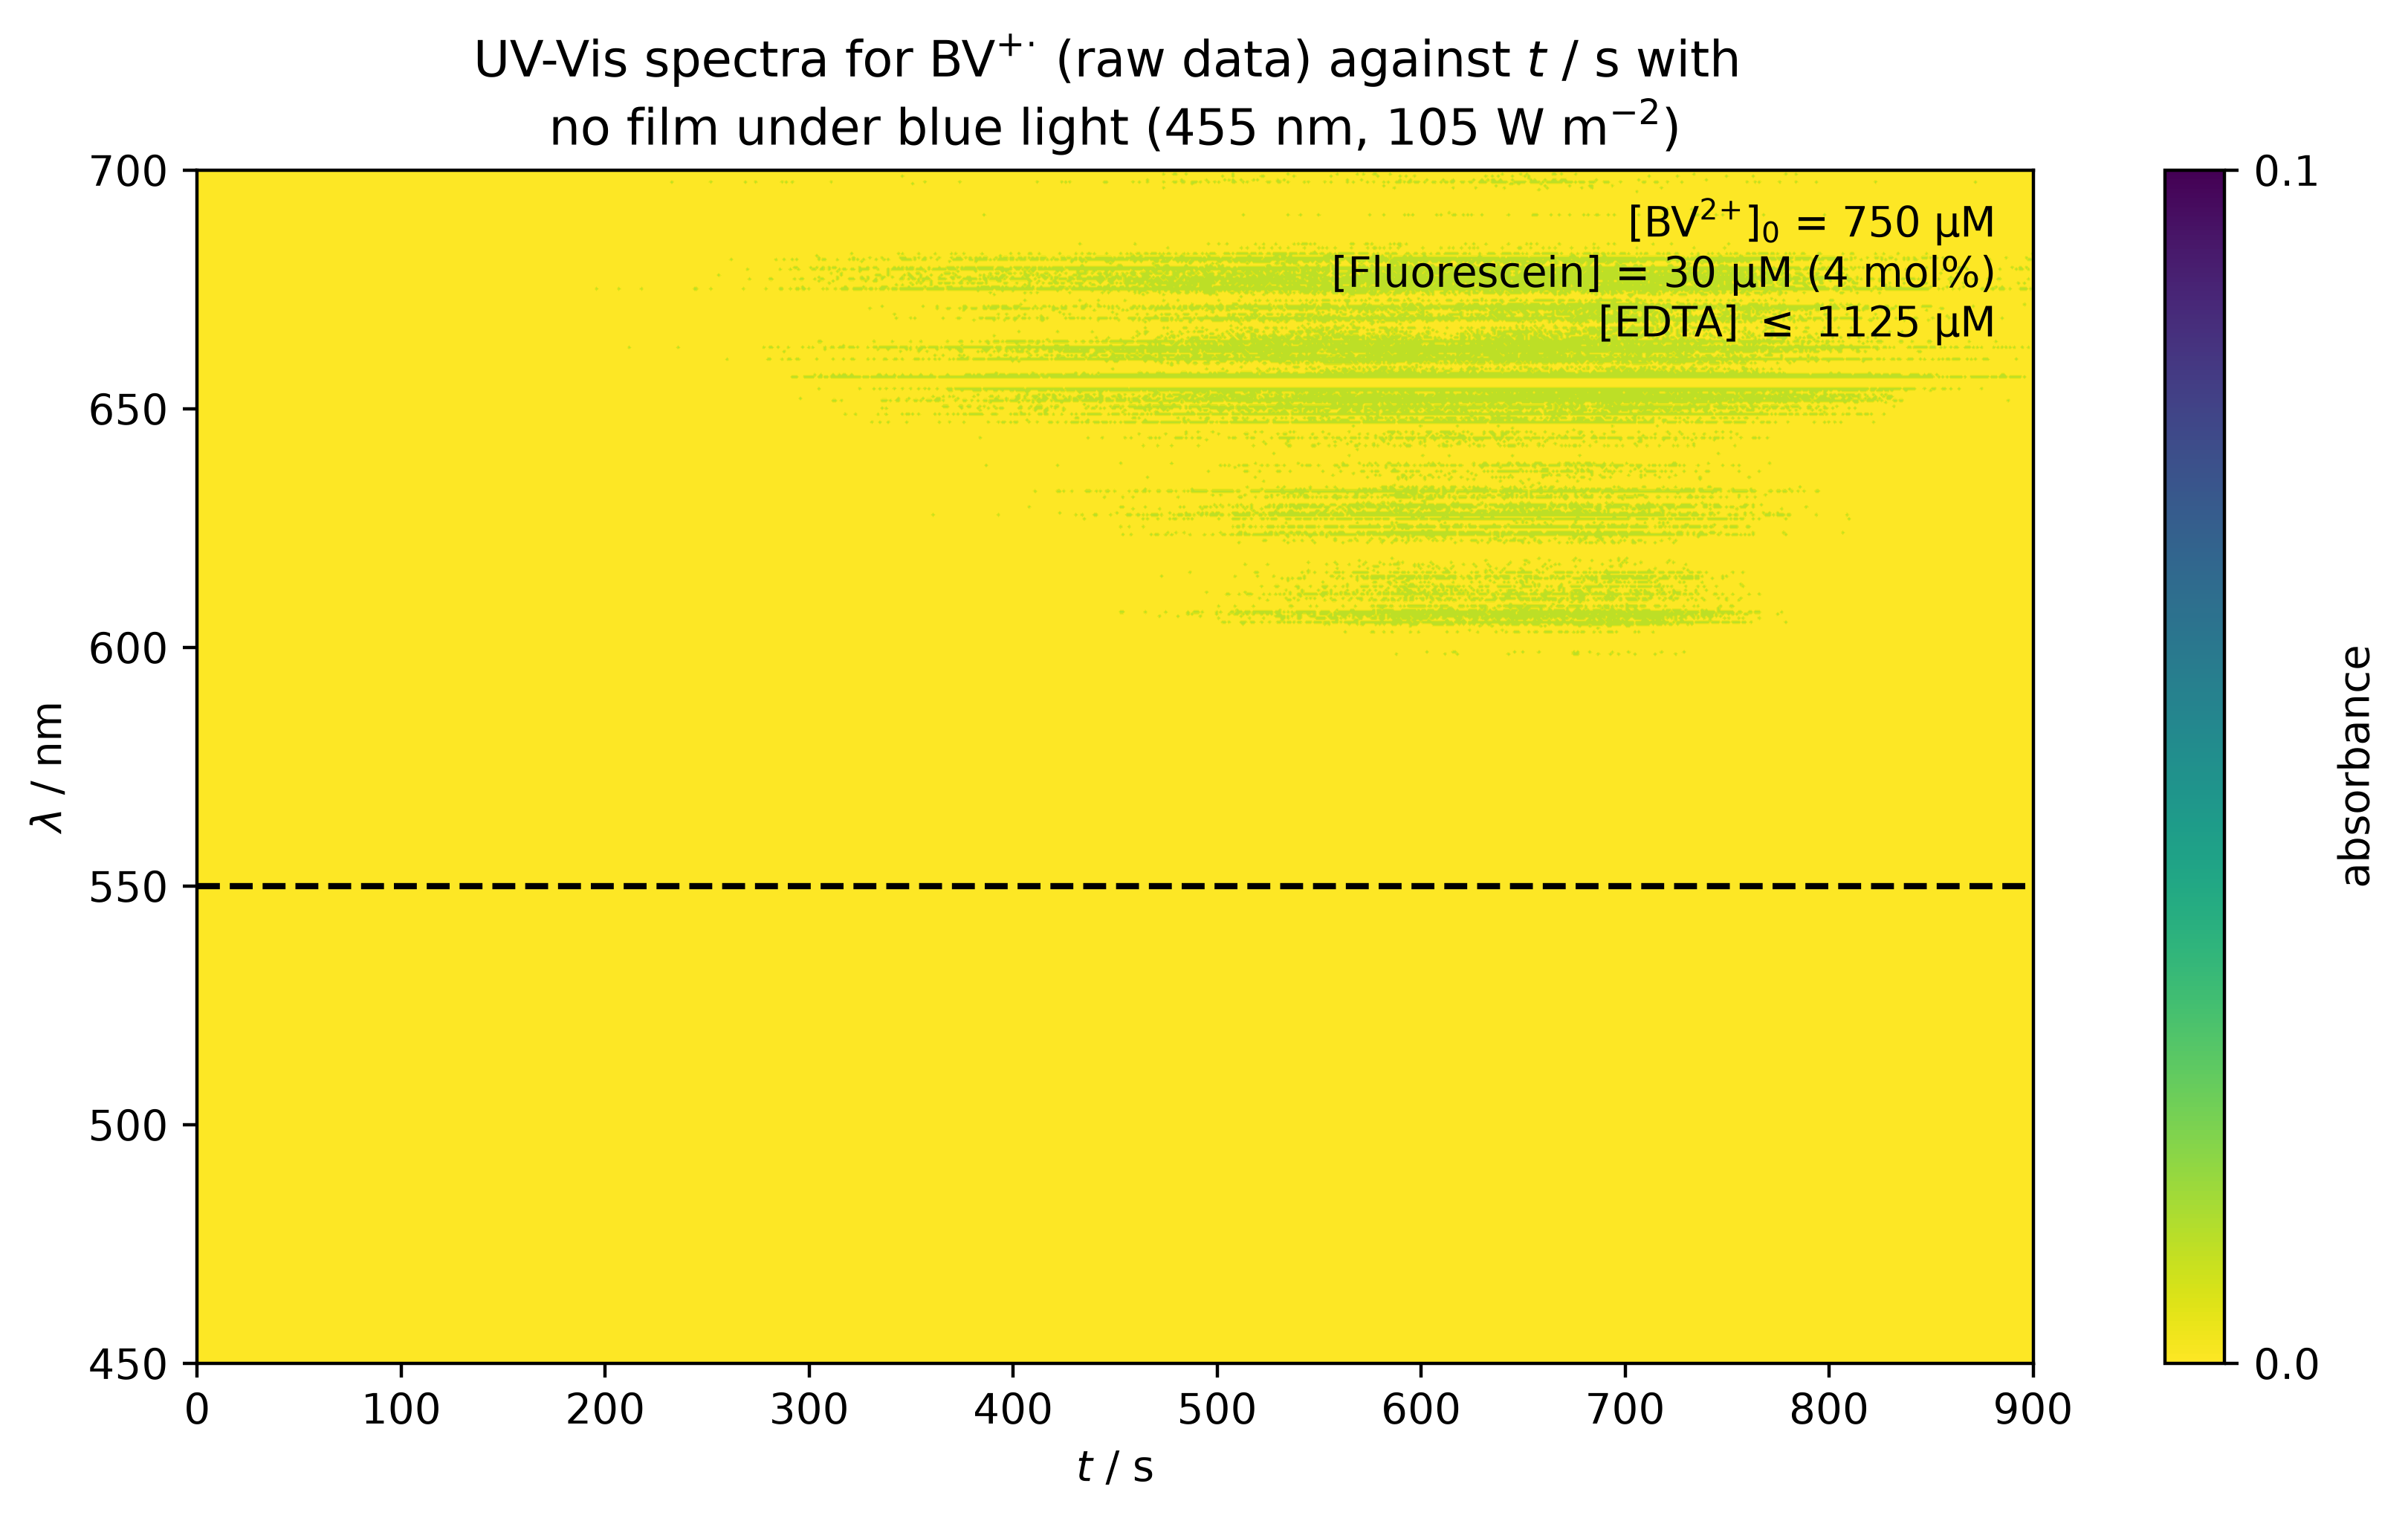

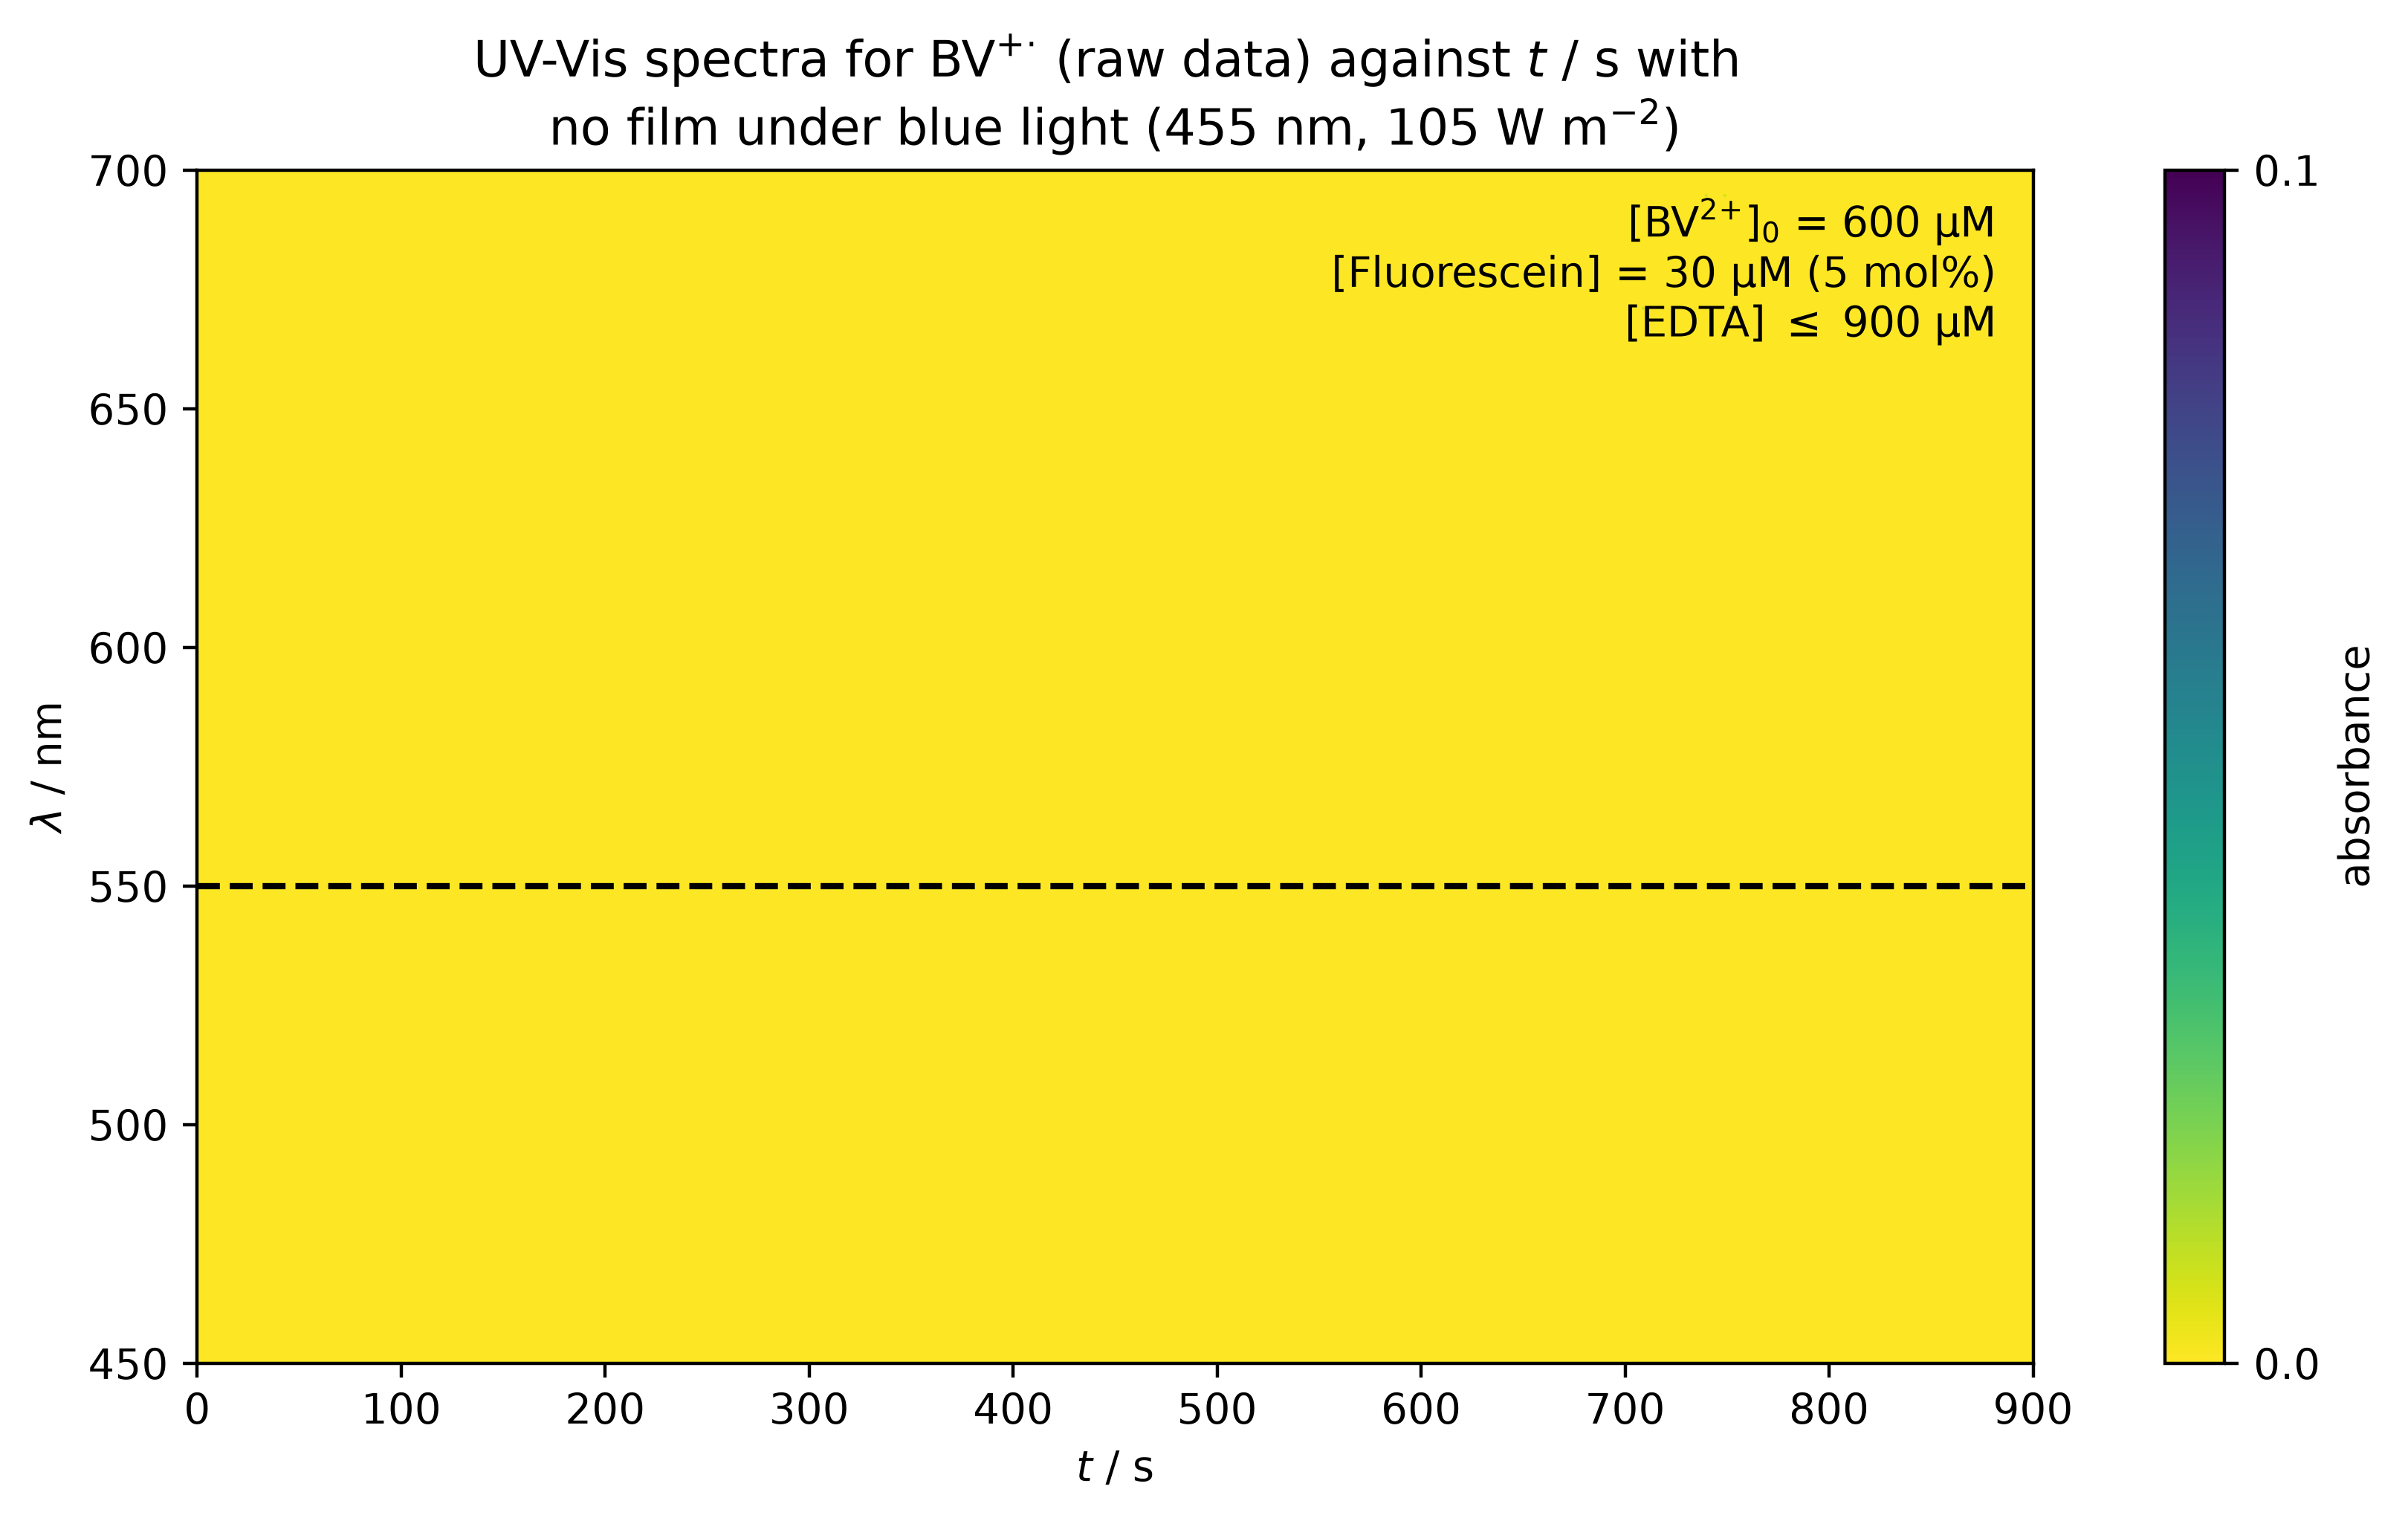

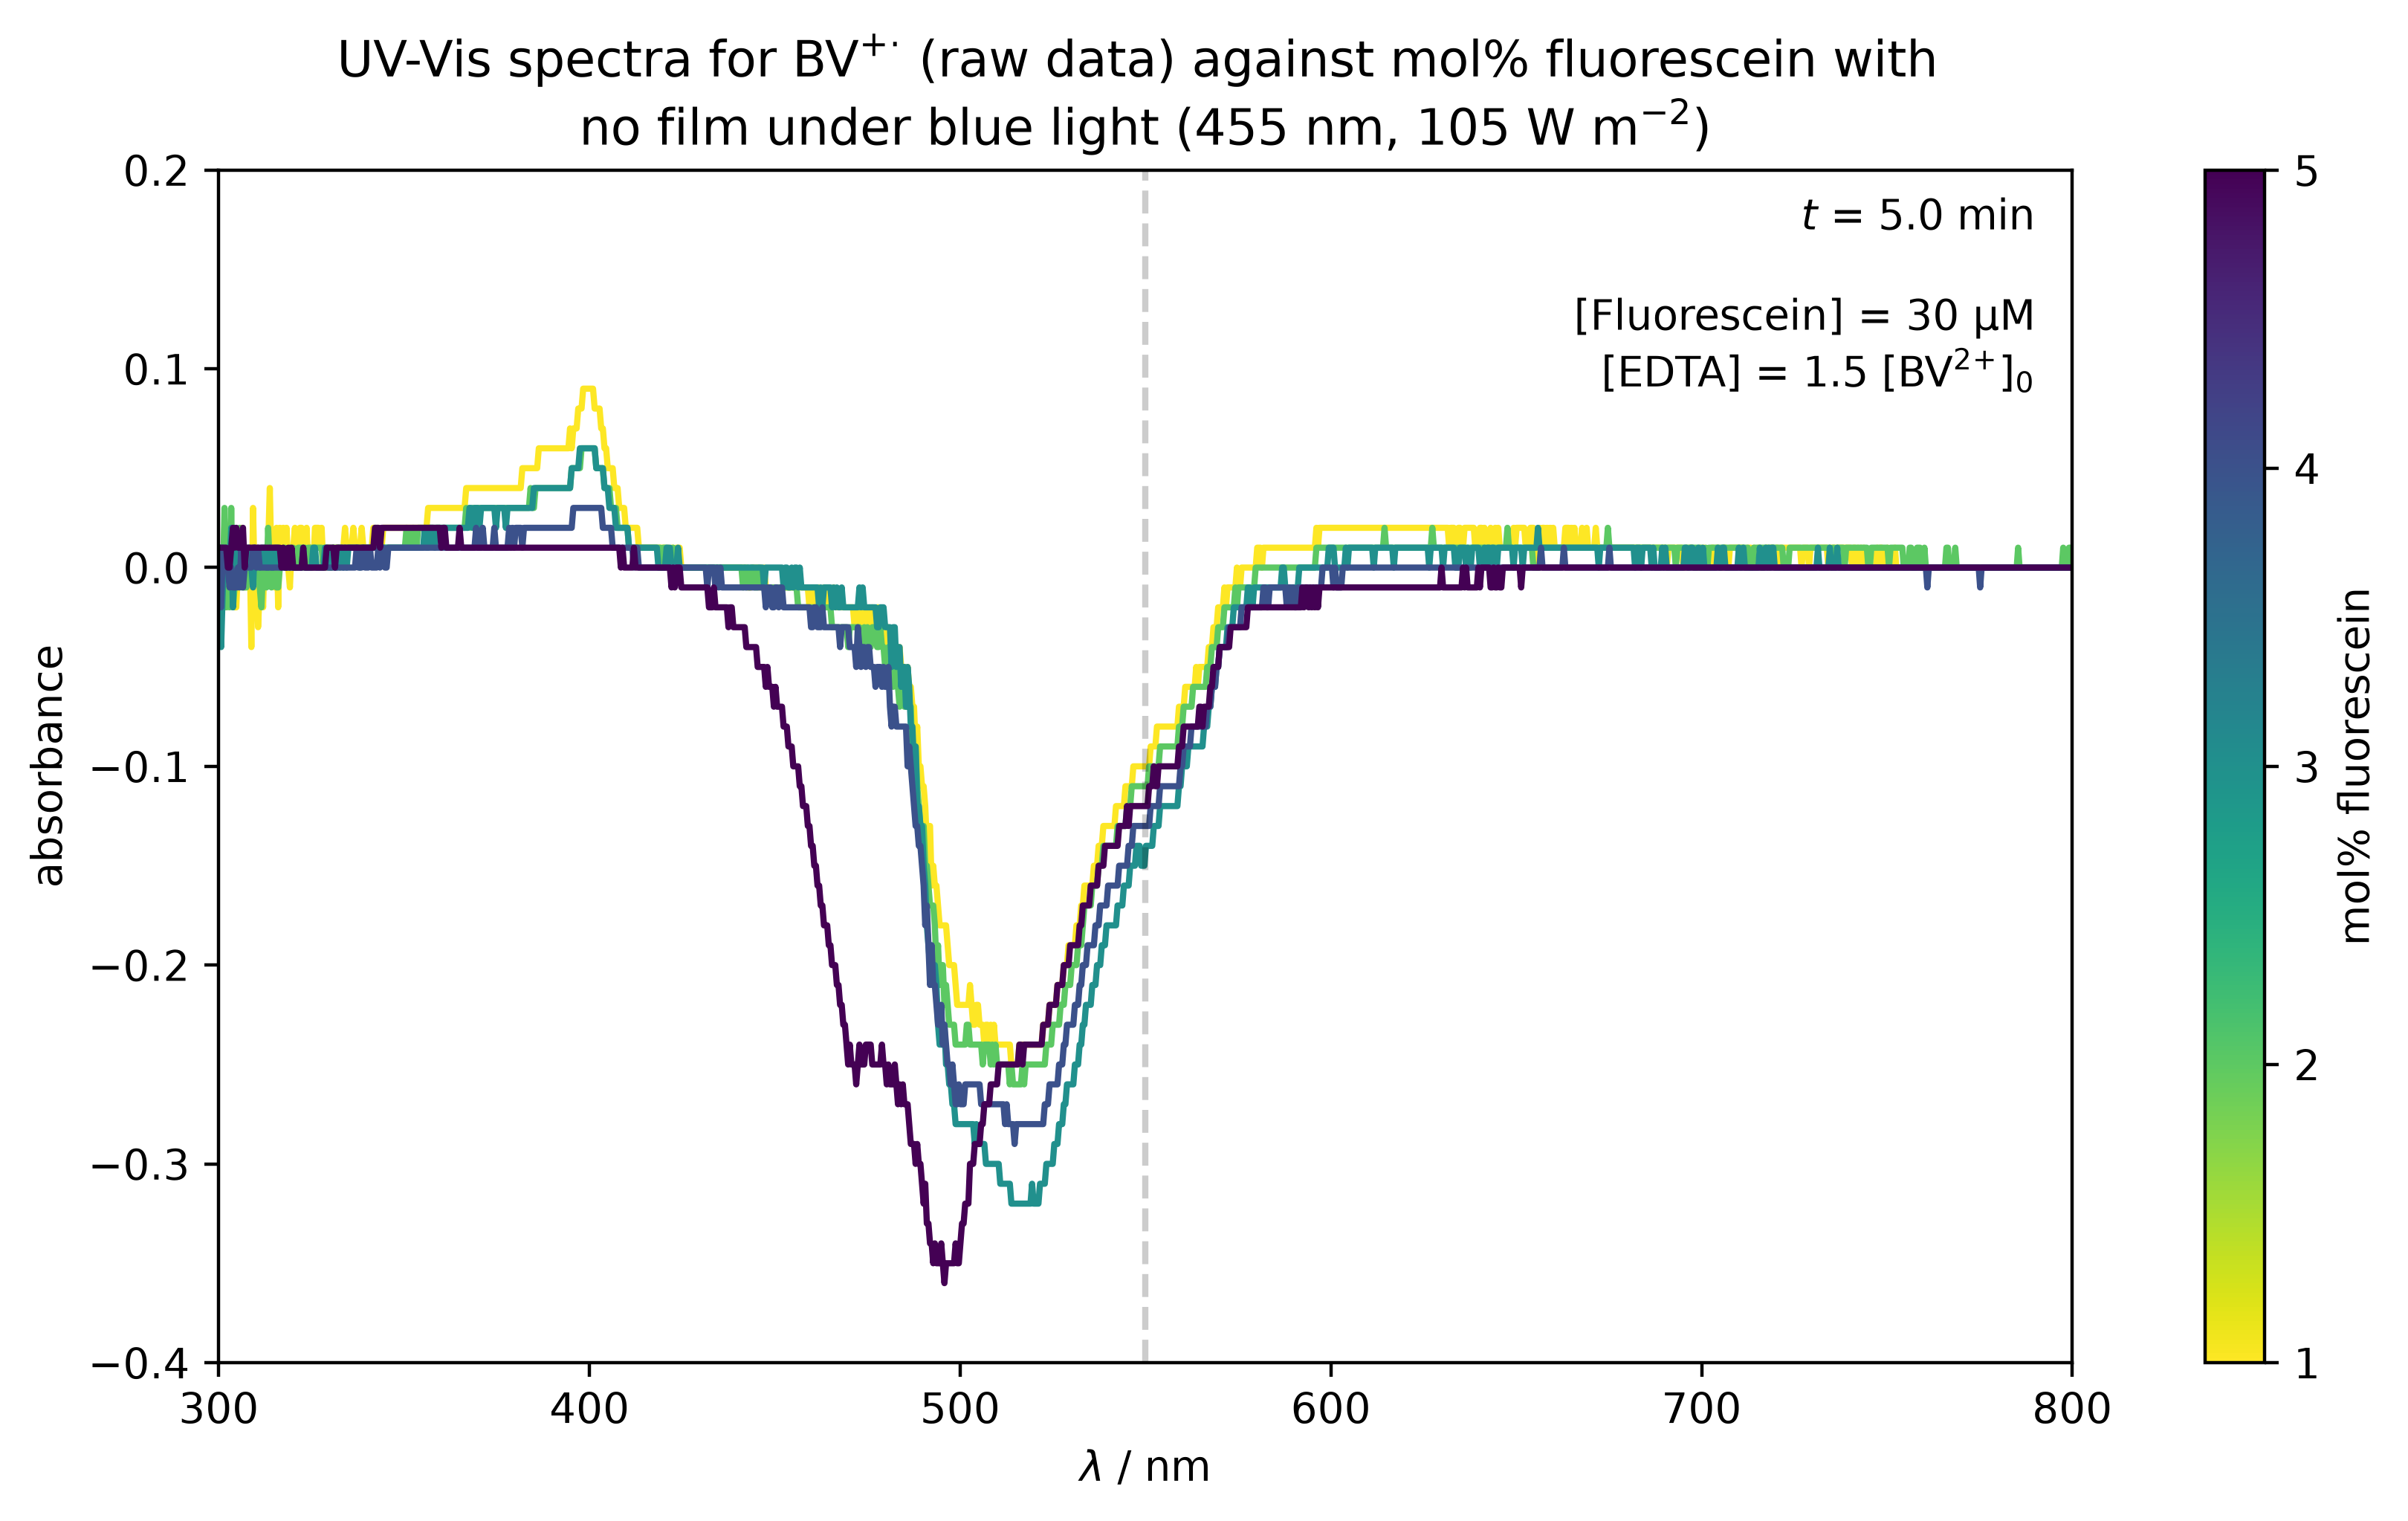

In [1]:
from lsmr_photocatalysis import Batch, X

"""
Batch reaction in the lightbox with blue 455 nm irradiation.

V(fluorescein, 5 mM, pH 7 buffer) = 18 ul (30 uM, 1-5 mol%),
V(BV2+, 30 mM, pH 7 buffer) = 60-300 ul, (600-3000 uM, depending on fluorescein mol%),
V(EDTA, saturated <25 mM, pH 7 buffer) = 108-540 ul (900-4500 mM, <1.5 eq of EV),
Made up to 3 ml with pH 7 buffer.
"""

x = 'BVfluorbatch'
duration = 15*60 # plot up to 15 min
t = 5*60 # see spectrum at 5 min

# (mol% fluorescein, start time) for each run, start time adjusted slightly to begin at linear region
runs = [(1, '13-01-00-000', 100),
        (2, '13-22-00-500', 0),
        (3, '13-43-00-000', 0),
        (4, '14-03-00-500', 100),
        (5, '14-23-00-000', 0)]

expts = []
for (p, start, istart) in runs:
    data = f'260729_Fluorescein_BV_EDTA_Batch/Fluorescein_BV_EDTA_Batch_{p}' # data folder name
    c0 = (100/p)*0.03e-3 # initial BV2+ concentration, back-calculated from mol% of PC
    details = f'[Fluorescein] = 30 μM ({p} mol%)\n[EDTA] 'rf'$\leq$ {c0*1.5*1e6:.0f} μM' # concentrations of reagents
    expts.append((Batch(data, start, c0, details, x, correction=False, duration=duration), istart))

for expt, istart in expts:
    expt.concvstimeplot(istart=istart, trial=100, r2threshold=0.8, interceptthreshold=1e-6)
for expt, istart in expts:
    expt.concvstimeplot(ln=True, istart=istart, trial=100, r2threshold=0.8, interceptthreshold=1e-6)
for expt, _ in expts:
    expt.spectrumvstimeplot(amin=0, amax=0.1)

Batch.spectrumvsconcplot([expt for expt, _ in expts], t, 
                         details = f'[Fluorescein] = 30 μM\n[EDTA] = 1.5 {X['BV0']}', 
                         cbarticks=[f'{p}' for p, _, _ in runs], 
                         cbarlabel = f'mol% fluorescein')